In [1]:
import numpy as np
import matplotlib.ticker as ticker
import matplotlib.pyplot as plt
from matplotlib.colors import rgb2hex
from mpl_toolkits.axes_grid1 import make_axes_locatable
from ezyrb import POD, RBF, Database, Linear, RegularGrid
from ezyrb import ReducedOrderModel as ROM
from scipy.interpolate import griddata
from datetime import datetime
import cupy as cp
from cupyx.scipy.ndimage import gaussian_filter as gaussian_filter_gpu
from smooth_POD_ROM.reduced_order_model import train_ROM_rw, get_predictions, get_predictions_gpu, get_improvement, L2_error_rw
from smooth_POD_ROM.pre_processing import (
    on_regular_grid, _gauss_2d, to_frequency, to_space, add_padding)
from smooth_POD_ROM.post_processing import sharpen, richardson_lucy, get_sigma, richardson_lucy2_gpu, get_sigma_batch
#from smooth_POD_ROM.io import get_data, get_field
#from smooth_POD_ROM.plotting import plot_mesh, plot_field, plot_structured_field
from copy import deepcopy
from scipy.ndimage import gaussian_filter
from scipy.fft import fft2, ifft2, fftshift, ifftshift
from scipy.signal import wiener, convolve2d
from skimage import restoration
from skimage.restoration import richardson_lucy
#import tvtk
import vtk
from vtk.util.numpy_support import vtk_to_numpy
import cv2
from datetime import datetime
from os import listdir
from os.path import isfile, join
import re

In [2]:
import matplotlib.pyplot as plt
import matplotlib as mpl
cmap = plt.colormaps.get_cmap("plasma")
single_column = 90  # mm
font_size_normal = 8

single_column_in = single_column/10/2.54
single_column_figure = (single_column_in, single_column_in/1.618)

plt.rcParams['font.size'] = font_size_normal
plt.rcParams["figure.figsize"] = single_column_figure

plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['legend.labelspacing'] = 0.25
plt.rcParams['legend.handlelength'] = 1.5
mpl.rc('text', usetex=True)
mpl.rc('font', family='serif', size=font_size_normal, serif='Computer Modern Roman')
pth = "../Plots/"

markevery = 40

In [3]:
pth_server_dbCoarseVTU = "//files.ad.ife.no/MatPro_files/Florian/damBreak_results/"
pth_local_dbCoarseOLD = "C:/Users/florianma/OneDrive - Institutt for Energiteknikk/Documents/convolution_paper/data/DamBreak/"
pth_local_dbCoarse = "C:/Users/florianma/OneDrive - Institutt for Energiteknikk/Documents/convolution_paper/data/DamBreakCoarse/"
pth_local_dbFine = "C:/Users/florianma/OneDrive - Institutt for Energiteknikk/Documents/convolution_paper/data/DamBreakFine/"
rank = 80
size_p_test = 20
timestep = 0.25
apply_threshold = False


n_x = n_y = 512
x = np.linspace(0, 0.584, n_x, endpoint=True)
y = np.linspace(0, 0.584, n_y, endpoint=True)
X, Y = np.meshgrid(x, y, indexing="ij")
is_wall = (0.292 <= X) & (X <= 0.316) & (Y <= 0.048)


case = {
    "sigma": 0.013,
    "c": 1,
    "num_iter": 10,
    "shape": X.shape,
    "x": x,  # for truncation of kernel and calculation of sgm
    "dx": x[1]-x[0],  # for truncation of kernel and calculation of sgm
    "mode": 'reflect'
}

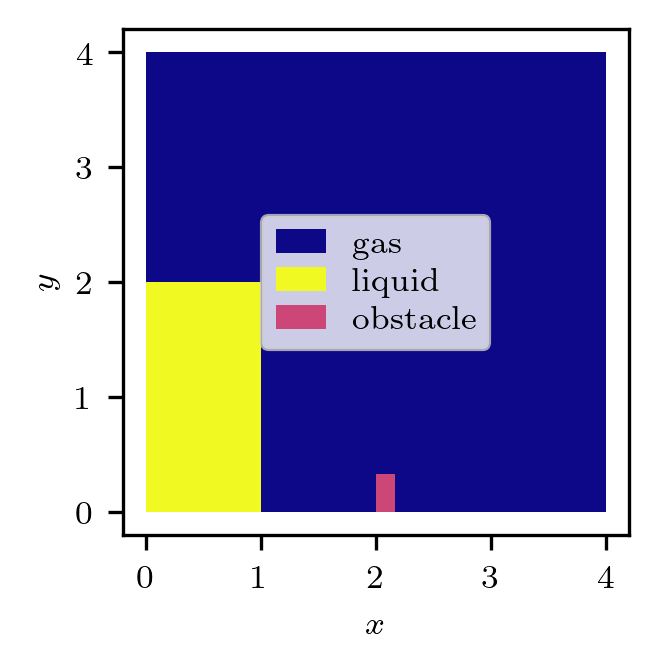

In [4]:
domain = np.array([
    [0, 0, 0],
    [2, 0, 0],
    [2, 0.32876, 0],
    [2.16438, 0.32876, 0],
    [2.16438, 0, 0],
    [4, 0, 0],
    [4, 4, 0],
    [0, 4, 0],
])
water = np.array([
    [0, 0, 0],
    [1, 0, 0],
    [1, 2, 0],
    [0, 2, 0],
])
obstacle = np.array([
    [2, 0, 0],
    [2, 0.32876, 0],
    [2.16438, 0.32876, 0],
    [2.16438, 0, 0],
])

c0 = rgb2hex(cmap(0), keep_alpha=True)
c5 = rgb2hex(cmap(0.5), keep_alpha=True)
c1 = rgb2hex(cmap(1.0), keep_alpha=True)

fig, ax = plt.subplots()
plt.fill(domain[:, 0], domain[:, 1], c0, alpha=1, label="gas")
plt.fill(water[:, 0], water[:, 1], c1, alpha=1, label="liquid")
plt.fill(obstacle[:, 0], obstacle[:, 1], c5, alpha=1, label="obstacle")
ax.set_aspect("equal")
ax.set_xlabel(r'$x$')
ax.set_ylabel(r'$y$')
#plt.xlim([0, 4])
#plt.ylim([0, 4])
plt.legend()
plt.savefig(pth+"/db_domain.pdf")
plt.show()

In [5]:
def plot_dam_snapshot(ax, ss, X, Y):
    cmap = plt.cm.viridis_r
    #cmap.set_under('C3')
    x = np.unique(X)
    dx = x[1]-x[0]
    y = np.unique(Y)
    dx = y[1]-y[0]
    extent = (np.min(x)-dx/2, np.max(x)+dx/2, np.min(y)-dx/2, np.max(y)+dx/2)
    cs = ax.imshow(ss.T, origin="lower", interpolation="linear", extent=extent, cmap=cmap, vmin=0, vmax=1)
    return cs

def get_field(file, n='alpha.water'):
    assert isfile(file), file+" is not a valid file name."
    if file.endswith(".vtu"):
        reader = vtk.vtkXMLUnstructuredGridReader()
        reader.SetFileName(file)
    else:
        reader = vtk.vtkGenericDataObjectReader()
        reader.SetFileName(file)
        reader.ReadAllScalarsOn()
        reader.ReadAllVectorsOn()
    reader.Update()

    data = reader.GetOutput()
    if n == "points":
        array = data.GetPoints().GetData()
    else:
        point_data = data.GetPointData()
        array = point_data.GetArray(n)
    return vtk_to_numpy(array)

def get_data(pth, nu_all, rho_all, timesteps=np.linspace(0.01, 1, 100)):
    if len(nu_all) == 0:
        return np.empty((100, 0)), np.empty((0, 2)), np.empty((0, 0))
    X = []
    params = []
    for n, r in zip(nu_all, rho_all):
        for ts in timesteps:
            file = "damBreak_m{:02.1f}_r{:02.1f}_t{:.2f}/internal.vtu".format(n, r, ts)
            file = "res_m{:04.4f}_r{:04.4f}_t{:.2f}/internal.vtu".format(n, r, ts)
            data = get_field(pth+file, 'alpha.water')
            X.append(data)
            params.append([n, r, ts])
    if len(timesteps) == 1:
        params = np.array(params)[:, :2]
    snapshots3D = np.array(X).T
    
    points3D = get_field(pth+file, 'points')
    forbidden_points = points3D[:, 2] > 0.0
    snapshots = snapshots3D[~forbidden_points, :]
    points = points3D[~forbidden_points, :2]
    return snapshots, params, points

In [6]:
# the training data is defined on a regular grid defined as:
nu_grid_c = 10*2**np.arange(0, 10, 1)
rho_grid_c = 10*2**np.arange(0, 8, 1)
nu_train_c, rho_train_c = np.meshgrid(nu_grid_c, rho_grid_c, indexing="ij")
nu_train_c, rho_train_c = nu_train_c.ravel(), rho_train_c.ravel()

In [7]:
ts = timestep
pth = pth_local_dbCoarseOLD  # pth_local_dbFine  # pth_local_dbCoarseOLD
print(pth+"t{:.2f}_mu_train.npy".format(ts))
mu_train = np.load(pth+"t{:.2f}_mu_train.npy".format(ts))
X_train = np.load(pth+"t{:.2f}_X_train.npy".format(ts)).T

mu_test = np.load(pth+"t{:.2f}_mu_test.npy".format(ts))
X_test = np.load(pth+"t{:.2f}_X_test.npy".format(ts)).T

#mu_val = np.load(pth+"t{:.2f}_mu_val.npy".format(ts))
#X_val = np.load(pth+"t{:.2f}_X_val.npy".format(ts)).T

points = np.load(pth+"points.npy")
print(points.shape, X_train.shape, mu_train.shape)
n_ss = len(X_train)

C:/Users/florianma/OneDrive - Institutt for Energiteknikk/Documents/convolution_paper/data/DamBreak/t0.25_mu_train.npy
(36705, 2) (80, 36705) (80, 2)


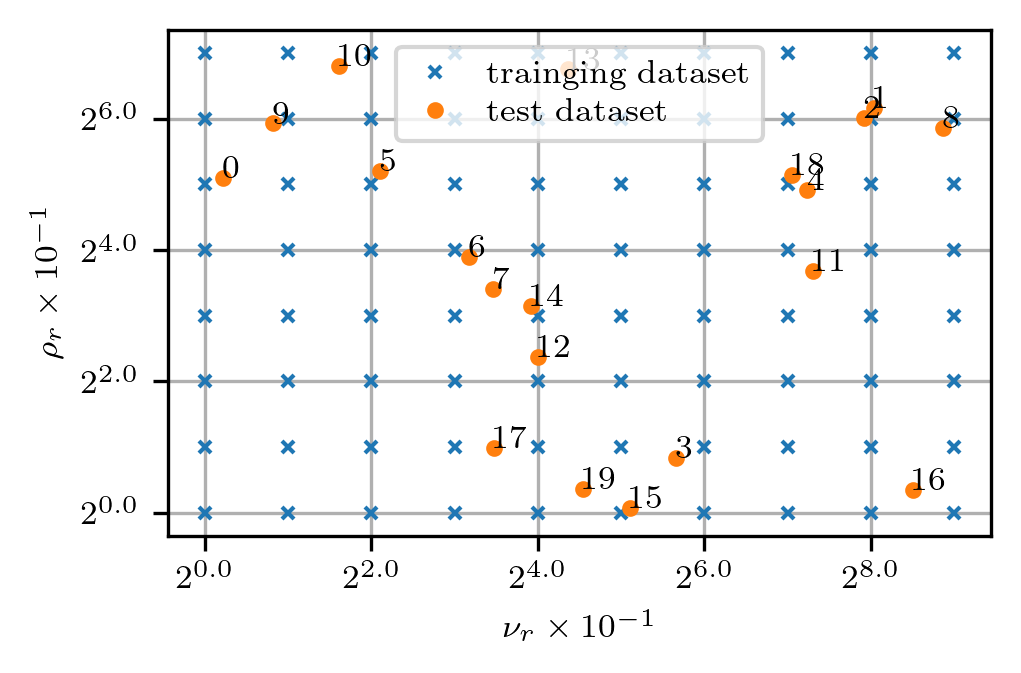

In [8]:
fig, ax = plt.subplots()
nu_test, rho_test = np.split(mu_test, 2, axis=-1)
#nu_val, rho_val = np.split(mu_val, 2, axis=-1)
plt.plot(nu_train_c, rho_train_c, lw=0.0, color='C0', marker='x', ms=3, label="trainging dataset")
plt.plot(nu_test, rho_test, lw=0.0, color='C1', marker='o', ms=3, label="test dataset")
#plt.plot(nu_val, rho_val, lw=0.0, color='C2', marker='+', ms=3, label="validation dataset")

ax.set_xscale('log', base=2)
ax.set_yscale('log', base=2)
ax.xaxis.set_major_locator(ticker.FixedLocator(nu_grid_c))
ax.yaxis.set_major_locator(ticker.FixedLocator(rho_grid_c))
ax.set_xticklabels(nu_grid_c)
ax.set_yticklabels(rho_grid_c)

ax.set_xlabel(r'$\nu_r \times 10^{-1}$')
ax.set_ylabel(r'$\rho_r \times 10^{-1}$')
ax.set_xticks(nu_grid_c)
ax.set_yticks(rho_grid_c)
ax.set_xticklabels([r'$2^{'+'{:.1f}'.format(e)+'}$' for e in np.log2(ax.get_xticks()/10)])
ax.set_yticklabels([r'$2^{'+'{:.1f}'.format(e)+'}$' for e in np.log2(ax.get_yticks()/10)])
ax.set_xticks(ax.get_xticks()[::2])
ax.set_yticks(ax.get_yticks()[::2])
#ax.text(0.0, 1.01, r'$\times 10$') #, fontsize=10, transform = gca().transAxes)
for i in range(len(nu_test)):
    ax.text(nu_test[i], rho_test[i], str(i))
ax.legend()
plt.grid(True)  # print(sgm, sz, ns)
#plt.title("dbCoarse")
plt.savefig(pth+"/db_datasets.pdf")
plt.show()

In [9]:
#X, Y, test_snapshot = on_regular_grid(points,  u_train[:, 0])
#m, n = u_train.shape


X_train_grid = np.empty((len(X_train), n_x*n_y))
X_test_grid = np.empty((len(X_test), n_x*n_y))
#X_val_grid = np.empty((len(X_val), n_x*n_y))

for u_set, u_set_grid in zip([X_train, X_test], [X_train_grid, X_test_grid]):
    print(points.shape, u_set.shape)
    gridded = griddata(points[:, :2], u_set.T, (X, Y), method="linear")
    failed = np.isnan(gridded)
    gridded[failed] = griddata(points[:, :2], u_set.T, (X, Y), method="nearest")[failed]
    u_set_grid[:] = gridded.reshape((n_x*n_y, len(u_set))).T
#     for j in range(len(u_set)):
#         gridded = griddata(points[:, :2], u_set[j], (X, Y), method="linear")
# #        if apply_threshold:
# #            gridded = threshold(gridded)
# #        gridded[is_wall] = 0.5
#         u_set_grid[j] = gridded.ravel()
gridded_shape = (n_x, n_y)

(36705, 2) (80, 36705)
(36705, 2) (20, 36705)


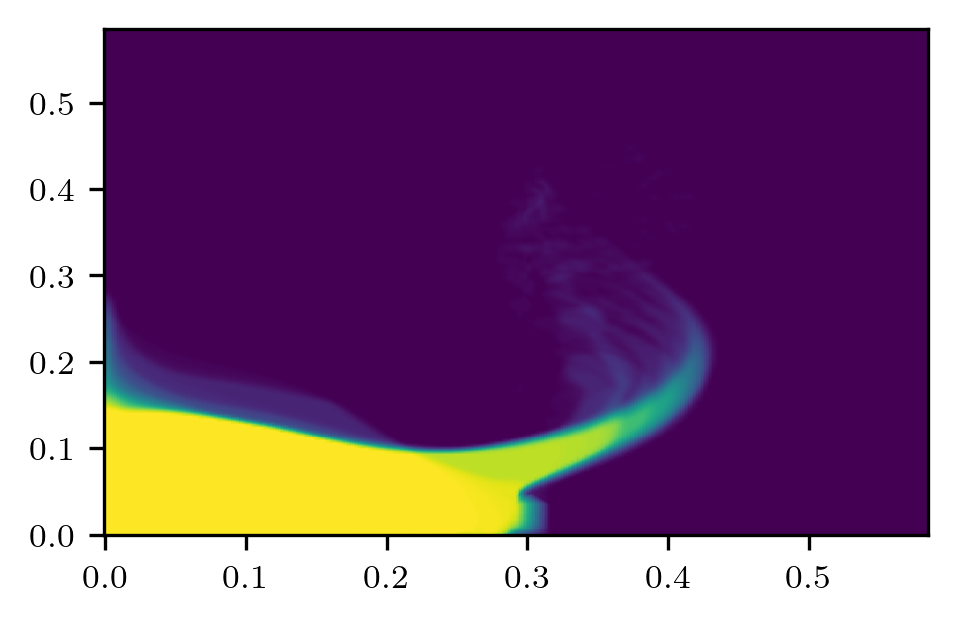

In [10]:
fig,ax = plt.subplots()
ax.pcolormesh(X, Y, np.mean(X_train_grid, axis=0).reshape(case["shape"]))
plt.show()

In [11]:
X_train_grid_s = np.empty_like(X_train_grid)
X_test_grid_s = np.empty_like(X_test_grid)
#X_val_grid_s = np.empty_like(X_val_grid)

sgm = case["sigma"] / case["dx"]
mode = case["mode"]
for X_set_grd, X_set_grd_s in zip([X_train_grid, X_test_grid], [X_train_grid_s, X_test_grid_s]):
    for j in range(len(X_set_grd)):
        ss2D = X_set_grd[j].reshape(case["shape"])
        X_set_grd_s[j] = gaussian_filter(ss2D, sigma=sgm, truncate=10, mode='reflect').ravel()

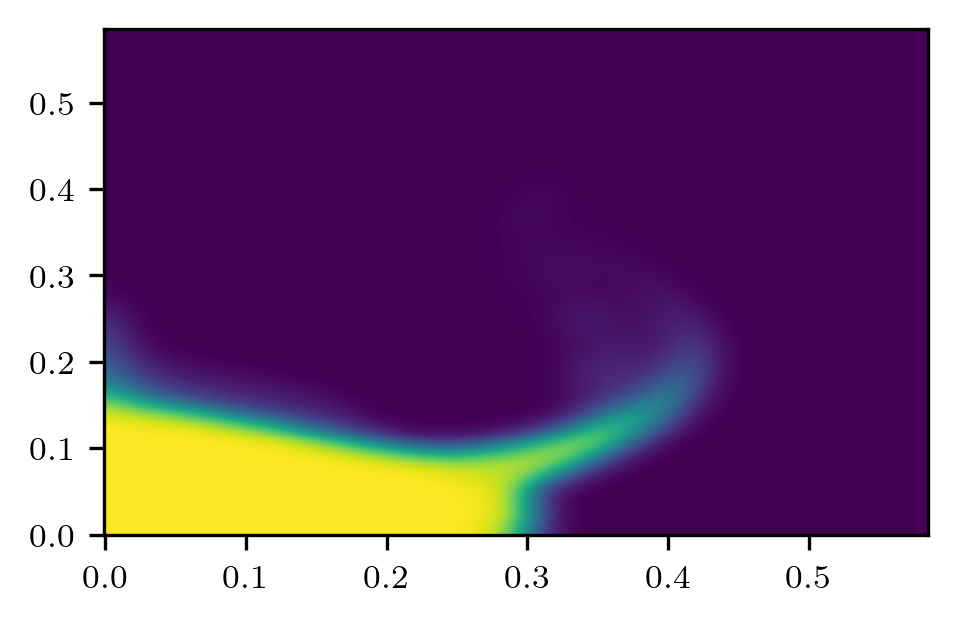

In [12]:
fig,ax = plt.subplots()
ax.pcolormesh(X, Y, np.mean(X_train_grid_s, axis=0).reshape(case["shape"]))
plt.show()
wall_grad = np.mean(X_train_grid_s, axis=0).reshape(case["shape"])[is_wall].copy()

In [13]:
# def _richardson_lucy_truncate(sgm, dx):
#     """Truncate for Gaussian kernel (shared by CPU and GPU RL)."""
#     truncate = 8
#     if sgm / dx > 800:
#         truncate = 1
#     elif sgm / dx > 400:
#         truncate = 2
#     elif sgm / dx > 200:
#         truncate = 3
#     elif sgm / dx > 100:
#         truncate = 4
#     elif sgm / dx > 50:
#         truncate = 5
#     elif sgm / dx > 25:
#         truncate = 5
#     return truncate

# def richardson_lucy_gpu(
#     x,
#     im_blur,
#     sgm,
#     num_iter=50,
#     damping=1,
#     clip=True,
#     mode="wrap",
#     monitor_convergence=False,
#     clip_min=0,
#     clip_max=1,
# ):
#     """GPU Richardson–Lucy deconvolution. Requires CuPy. Same signature as richardson_lucy."""

#     if not len(im_blur.shape) == 2:
#         warnings.warn("image needs to be 2D")
#     if monitor_convergence:
#         raise ValueError("monitor_convergence not implemented in GPU version")
#     dx = float(x[1] - x[0])
#     truncate = _richardson_lucy_truncate(sgm, dx)

#     im_deconv = im_blur.copy()
#     eps = 1e-7
#     sigma_pixels = sgm / dx
#     if clip:
#         target_mass = cp.sum(im_blur)
#     print("renormalizing")
#     for k in range(num_iter):
#         blurred = gaussian_filter_gpu(im_deconv, sigma=sigma_pixels, truncate=truncate, mode=mode)
#         #blurred[cp.abs(blurred) < eps] = eps
#         blurred = cp.maximum(blurred, eps)

#         relative_blur = im_blur / blurred
#         error_estimate = gaussian_filter_gpu(relative_blur, sigma=sigma_pixels, truncate=truncate, mode=mode)
#         if damping:
#             error_estimate = cp.clip(error_estimate, 1 - damping, 1 + damping)
#         im_deconv *= error_estimate
#         if clip:
#             im_deconv = cp.clip(im_deconv, clip_min, clip_max)
#             mass = cp.sum(im_deconv)
#             if mass > 0:
#                 im_deconv *= target_mass / mass
#     im_deconv_np = cp.asnumpy(im_deconv)
#     return im_deconv_np, False

# def clip_redistribute_weighted_gpu(y, target_mass, lo=0.0, hi=1.0, tol=1, max_iter=10):
#     """
#     Redistribution is weighted by available room:
#       - add mass proportional to (hi - u)
#       - remove mass proportional to (u - lo)
#     """
#     u = cp.clip(y, lo, hi)
#     for _ in range(max_iter):
#         delta = target_mass - cp.sum(u)
#         print(delta)
#         if cp.abs(delta) < tol:
#             return u, True
#         active = (u > lo + tol) & (u < hi - tol)
#         if not bool(active.any().item()):
#             return u, False
#         if delta > 0:
#             w = cp.where(active, hi - u, 0.0)   # room to go up
#         else:
#             w = cp.where(active, u - lo, 0.0)   # room to go down
#         wsum = cp.sum(w)
#         if wsum < tol:
#             return u, False
#         u = u + delta * (w / wsum)
#         u = cp.clip(u, lo, hi)
#     success = bool(cp.abs(target_mass - cp.sum(u)).item() < 10 * tol)
#     return u, success

# def richardson_lucy2_gpu(
#     x,
#     im_blur,
#     sgm,
#     num_iter=50,
#     damping=1,
#     clip=True,
#     mode="wrap",
#     monitor_convergence=False,
#     clip_min=0,
#     clip_max=1,
# ):
#     """GPU Richardson–Lucy deconvolution. Requires CuPy. Same signature as richardson_lucy."""

#     if not len(im_blur.shape) == 2:
#         warnings.warn("image needs to be 2D")
#     if monitor_convergence:
#         raise ValueError("monitor_convergence not implemented in GPU version")
#     dx = float(x[1] - x[0])
#     truncate = _richardson_lucy_truncate(sgm, dx)

#     im_deconv = im_blur.copy()
#     eps = 1e-7
#     sigma_pixels = sgm / dx
#     target_mass = cp.sum(im_blur)
#     #print("v3")
#     for k in range(num_iter):
#         im_deconv[is_wall] = wall_grad
#         blurred = gaussian_filter_gpu(im_deconv, sigma=sigma_pixels, truncate=truncate, mode=mode)
#         #blurred[cp.abs(blurred) < eps] = eps
#         blurred = cp.maximum(blurred, eps)

#         relative_blur = im_blur / blurred
#         error_estimate = gaussian_filter_gpu(relative_blur, sigma=sigma_pixels, truncate=truncate, mode=mode)
#         error_estimate = cp.maximum(error_estimate, eps)
#         #if damping and damping>0:
#         #    error_estimate = cp.clip(error_estimate, 1 - damping, 1 + damping)
#         # # 1.
#         alpha = 1.0
#         trial = im_deconv * error_estimate**alpha
#         im_deconv = trial
#         # im_deconv, ok = clip_redistribute_weighted_gpu(im_deconv, target_mass=target_mass, lo=clip_min, hi=clip_max)
#         # im_deconv = project_box_mass_gpu(
#         #     trial,
#         #     target_mass=target_mass,
#         #     lo=clip_min,
#         #     hi=clip_max,
#         #     mask_fixed=is_wall,
#         #     fixed_values=wall_grad,
#         # )
#         # # 2.
#         # proposal = im_deconv * error_estimate
#         # im_deconv = im_deconv + (1 - im_deconv) * (proposal - im_deconv)
#         # 3.
#         #proposal = im_deconv * error_estimate
#         #im_deconv = proposal / (1 - im_deconv + proposal)

#         #mass = cp.sum(im_deconv)
#         #deficit = target_mass - mass
#         #if deficit > 0:
#         #    capacity = cp.maximum(clip_max - im_deconv, 0)
#         #    cap_sum = cp.sum(capacity)
#         #    if cap_sum > 0:
#         #        im_deconv += deficit * capacity / cap_sum
#         # # 4.
#         # im_deconv *= error_estimate
#         # im_deconv = im_deconv / (1 + im_deconv)
#         if clip:
#             im_deconv = cp.clip(im_deconv, clip_min, clip_max)
#             mass = cp.sum(im_deconv)
#             if mass > 0:
#                 im_deconv *= target_mass / mass
#     im_deconv_np = cp.asnumpy(im_deconv)
#     return im_deconv_np, False

# def get_predictions_gpu(sROM, mu_, sigma, c, num_iter, shape, x, sROM_only=False, monitor_progress_postprocessing=False, monitor_convergence=False, sigmaD="calc_based_on_distance", **kwargs):
#     mu_ = np.asarray(mu_)
#     X_test_sROM = sROM.predict(mu_).snapshots_matrix
#     mu_train = sROM.database.parameters_matrix
#     data = X_test_sROM
#     if sROM_only:
#         return data, None
#     mode = kwargs.get("mode", "wrap")

#     if monitor_convergence:
#         deconvolved = np.ones((*data.shape, num_iter))
#     else:
#         deconvolved = np.empty_like(data)
#     # Transfer all data to GPU once
#     data_gpu = cp.asarray(data.astype(np.float32))
#     for j in range(len(mu_)):
#         if isinstance(sigmaD, np.ndarray):
#             sgm_est = sigmaD[j]
#         elif sigmaD == "calc_based_on_distance":
#             sgm_est = get_sigma(sigma, mu_[j][None, ...], mu_train, c=c)
#         else:
#             raise ValueError("unknown method for sigmaD.")
#         res = richardson_lucy2_gpu(x, data_gpu[j].reshape(shape), sgm_est, num_iter, mode=mode, monitor_convergence=monitor_convergence)[0].reshape(deconvolved[j].shape)
#         deconvolved[j] = res
#         if monitor_progress_postprocessing:
#             print(j, end=", ")
#     X_test_sROMs = deconvolved
#     return X_test_sROM, X_test_sROMs

In [14]:
from scipy.optimize import minimize
from scipy.optimize import direct, Bounds

def rmv_wall_inplace(X):
    for j in range(len(X)):
        rmw = X[j].reshape(gridded_shape)
        rmw[is_wall] = wall_grad
        X[j] = rmw.ravel()
    return

def smoothen_GPU(X_train_gpu, shape, sgm, mode):
    #X_train_gpu = cp.asarray(X_train.reshape(-1, *shape).astype(np.float32))
    m0 = cp.sum(X_train_gpu, axis=(1, 2), keepdims=True)
    out = gaussian_filter_gpu(X_train_gpu, sigma=(0, sgm, sgm), truncate=8, mode=mode)
    m1 = cp.sum(out, axis=(1, 2), keepdims=True)
    out = out * cp.where(m1 > 0, m0 / m1, 1.0)
    X_train_s = cp.asnumpy(out).reshape(len(X_train_gpu), -1)
    return X_train_s


def target_function_oracle_coeff(case, X_train_grid, X_train_grid_gpu, mu_set, X_set_e=None, X_set_eGPU=None):
    sgm = case["sigma"] / case["dx"]
    sigma = case["sigma"]
    mode = case["mode"]
    shape = case["shape"]
    mu_train = case["mu_train"]
    sigmaD = case["sigmaD"]
    c = case["c"]
    x = case["x"]
    num_iter = case["num_iter"]
    print(case["sigma"],  case["c"], sigmaD[0], case["num_iter"], end=" ")

    X_train_grid_s = smoothen_GPU(X_train_grid_gpu, shape, sgm, mode)
    X_set_e_s = smoothen_GPU(X_set_eGPU, shape, sgm, mode)
    Q1, R1 = np.linalg.qr(X_train_grid.T, mode="reduced")
    Q2, R2 = np.linalg.qr(X_train_grid_s.T, mode="reduced")
    #print(X_train_grid.shape, Q1.shape, X_set_e.shape)
    X_set_ROM = (Q1 @ (Q1.T @X_set_e.T)).T
    X_set_sROM = (Q2 @ (Q2.T @X_set_e_s.T)).T

    # X_test_sROM, X_test_sROMs = get_predictions_gpu(my_sROM, mu_test, **case)
    data_gpu = cp.asarray(X_set_sROM.astype(np.float32))
    deconvolved_gpu = cp.empty_like(data_gpu)
    t1 = datetime.now()
    if isinstance(sigmaD, np.ndarray):
        sgm_est = sigmaD
    elif sigmaD == "calc_based_on_distance":
        sgm_est = get_sigma_batch(sigma, mu_set, mu_train, c=c)
    for j in range(len(mu_set)):
        res = richardson_lucy2_gpu(x, data_gpu[j].reshape(shape), sgm_est[j], num_iter, mode=mode, clip_max=1.0)[0].reshape(deconvolved_gpu[j].shape)
        deconvolved_gpu[j] = res
    t2 = datetime.now()
    X_set_sROMs = cp.asnumpy(deconvolved_gpu)
    rmv_wall_inplace(X_set_ROM)
    rmv_wall_inplace(X_set_sROM)
    rmv_wall_inplace(X_set_sROMs)

    mean_ROM, mean_sROM, mean_sROMs, improvement = get_improvement(
        X_set_e, X_set_ROM, X_set_sROM, X_set_sROMs, norm=L2_error_rw, scaler=None
    )
    print(mean_ROM, mean_sROM, mean_sROMs, (t2-t1).total_seconds(), improvement)
    return mean_ROM, mean_sROM, mean_sROMs, X_set_ROM, X_set_sROM, X_set_sROMs



def optimize_hyperparameters(case):
    sigma_opt = 0.013

    def target(params):
        case["sigma"], case["c"], case["num_iter"] = params[0], False, int(params[2])
        case["sigmaD"][:] = params[1]
        return target_function(case)[2]
    #bounds = Bounds([0.001, 0, 1], [5 * sigma_opt, 2, 50])
    bounds = Bounds([0.001, 0.001, 1], [5 * sigma_opt, 5 * sigma_opt, 200])
    res = direct(target, bounds, eps=1e-2, len_tol=0.01)  # max side length_abs=[0.006, 0.25]
    print(
        "optimization result for sigma:",
        res["x"][0],
        "bounds",
        0.001,
        5 * sigma_opt,
        "guess:",
        sigma_opt,
    )
    print("optimization result for c:", res["x"][1], "bounds", 0, 2)
    print(res.message)
    # TODO: check if bounds were OK
    return res["x"]

case = {
    "sigma": 0.013,
    "c": None,
    "num_iter": 10,
    "shape": gridded_shape,
    "x": x,  # for truncation of kernel and calculation of sgm
    "dx": x[1]-x[0],  # for truncation of kernel and calculation of sgm
    "mode": 'reflect',
    "sigmaD": np.zeros((len(mu_test),))  # sigma_D given for each n_test
        }

In [15]:
# parameters = optimize_hyperparameters(case)

X_train_grid_gpu = cp.asarray(X_train_grid.reshape(-1, *gridded_shape).astype(np.float32))
m0 = cp.sum(X_train_grid_gpu, axis=(1,2), keepdims=True)
rmv_wall_inplace(X_test_grid)

X_test_grid_gpu = cp.asarray(X_test_grid.reshape(-1, *gridded_shape).astype(np.float32))

def _target1(params):
    case["c"] = False
    case["mu_train"] = mu_train
    case["sigma"] = case["sigmaD"][:] = params[0]#, params[1]
    return target_function_oracle_coeff(case, X_train_grid, X_train_grid_gpu, mu_test, X_set_e=X_test_grid, X_set_eGPU=X_test_grid_gpu)[2]

def _target2(params):
    case["c"] = False
    case["mu_train"] = mu_train
    case["sigma"], case["sigmaD"][:] = params[0], params[1]
    return target_function_oracle_coeff(case, X_train_grid, X_train_grid_gpu, mu_test, X_set_e=X_test_grid, X_set_eGPU=X_test_grid_gpu)[2]

rank = len(mu_train)
num_iter = 20
sigma_opt = 0.23/rank
bounds1 = Bounds([0.0001], [3 * sigma_opt])
bounds2 = Bounds([0.001, 0.001], [2 * sigma_opt, 3 * sigma_opt])
bounds3 = Bounds([0.001, 0], [2 * sigma_opt, 3])

#bounds = Bounds([0.001, 0, 1], [5 * sigma_opt, 5, 200])
case["num_iter"] = num_iter
res = direct(_target1, bounds1, eps=1e-2, len_tol=0.01)
params_opt_best_coeff = res["x"]
_target1(res["x"])
print("DIRECT result:", res["x"], "mean_sROMs (min) =", res["fun"])

0.004362500000000001 False 0.004362500000000001 20 0.022496011229473895 0.031968593098931145 0.024337593864323222 0.907236 8.186262960415476
0.007204166666666667 False 0.007204166666666667 20 0.022496011229473895 0.04530159440095364 0.021475563603939207 0.884236 -4.536126938795775
0.0015208333333333337 False 0.0015208333333333337 20 0.022496011229473895 0.022752898182116985 0.025178878428278494 0.663428 11.925968436971402
0.00815138888888889 False 0.00815138888888889 20 0.022496011229473895 0.04957937287300447 0.02183389079397136 0.956807 -2.943279271816138
0.006256944444444444 False 0.006256944444444444 20 0.022496011229473895 0.040890970634730135 0.021794897054921956 0.802161 -3.1166155075231785
0.0053097222222222235 False 0.0053097222222222235 20 0.022496011229473895 0.036404883316625905 0.022743301599844126 0.866708 1.0992631886947066
0.0034152777777777784 False 0.0034152777777777784 20 0.022496011229473895 0.027846103683621205 0.025993292069778386 0.890144 15.546226416007528
0.007

In [25]:
X_train_grid_gpu = cp.asarray(X_train_grid.reshape(-1, *gridded_shape).astype(np.float32))
m0 = cp.sum(X_train_grid_gpu, axis=(1,2), keepdims=True)
rmv_wall_inplace(X_test_grid)

X_test_grid_gpu = cp.asarray(X_test_grid.reshape(-1, *gridded_shape).astype(np.float32))

case["c"] = False
case["mu_train"] = mu_train
case["num_iter"] = 20
case["sigma"], case["sigmaD"][:] = 0.0072, 0.0072
mean_ROM, mean_sROM, mean_sROMs, X_test_ROM, X_test_sROM, X_test_sROMs = target_function_oracle_coeff(case, X_train_grid, X_train_grid_gpu, mu_test, X_set_e=X_test_grid, X_set_eGPU=X_test_grid_gpu)


0.0072 False 0.0072 20 0.022496011229473895 0.04528244884424722 0.021470402764246478 0.89988 -4.559068071070669


0 0.0 -0.092317920546481 -0.029746296 0.0
0 1.0 1.1576608383061384 1.0097967 1.0
0 33049.566333591334 33024.10824322646 33027.86 33015.54


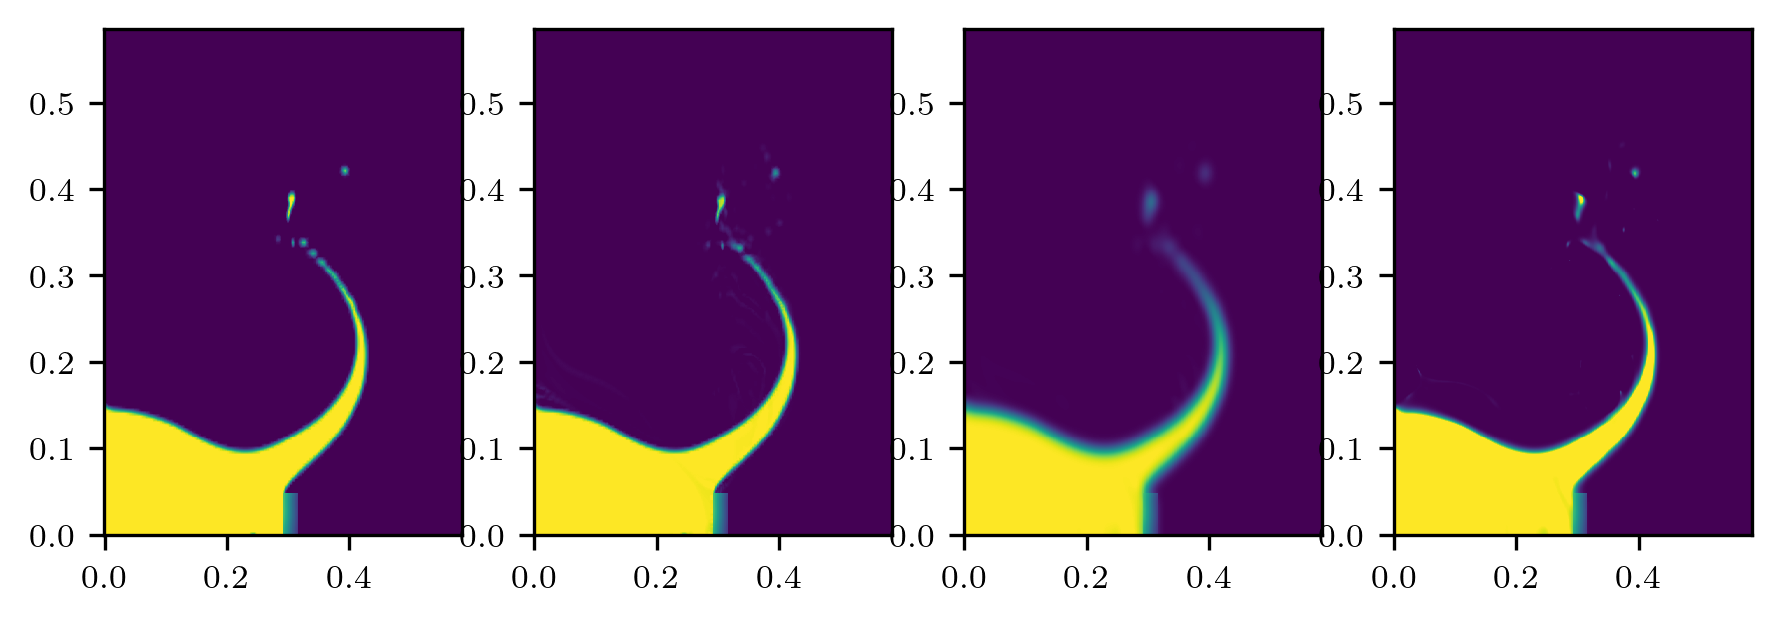

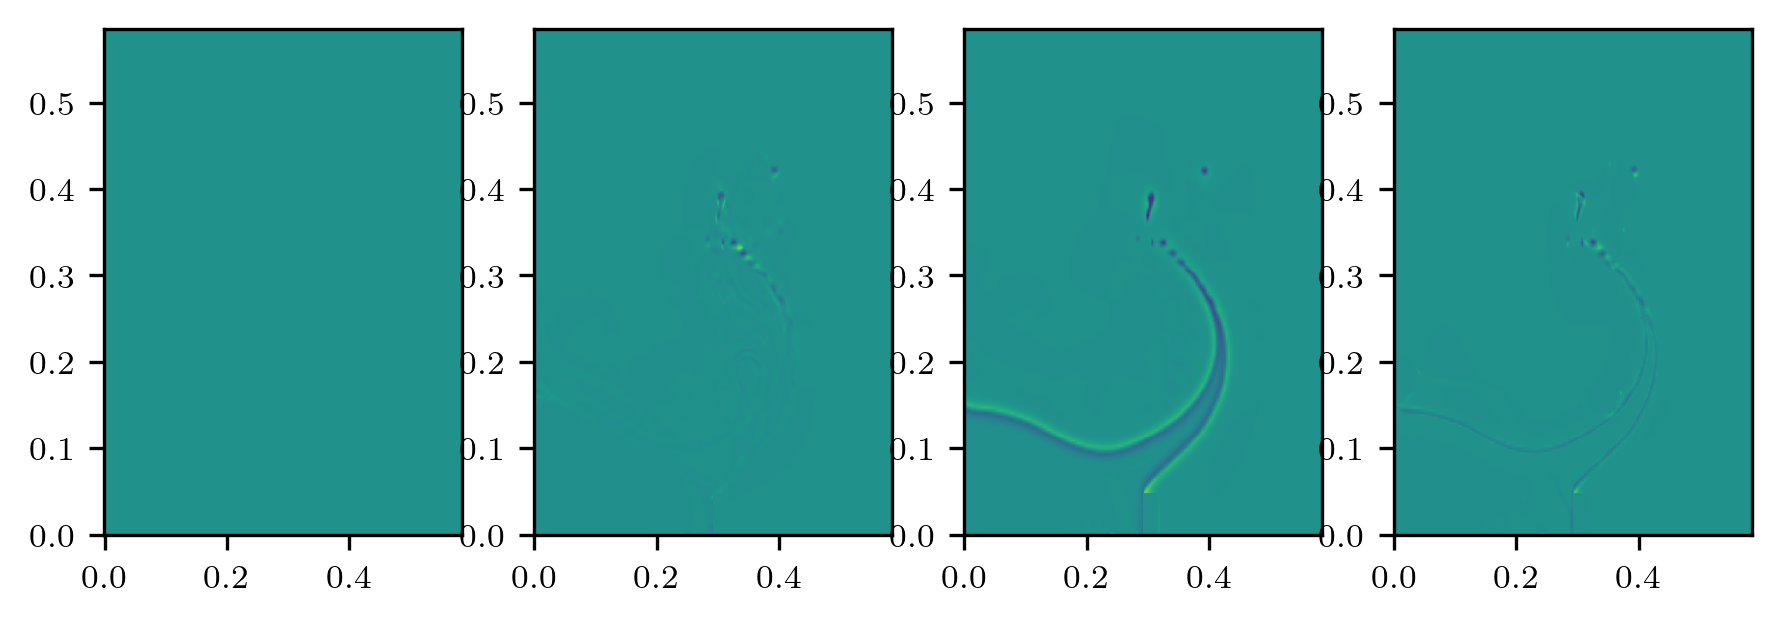

1 0.0 -0.08919162574897842 -0.02446185 0.0
1 1.0 1.1053930422167997 1.0171523 1.0
1 33092.21789970486 33101.88334205292 33077.895 33070.57


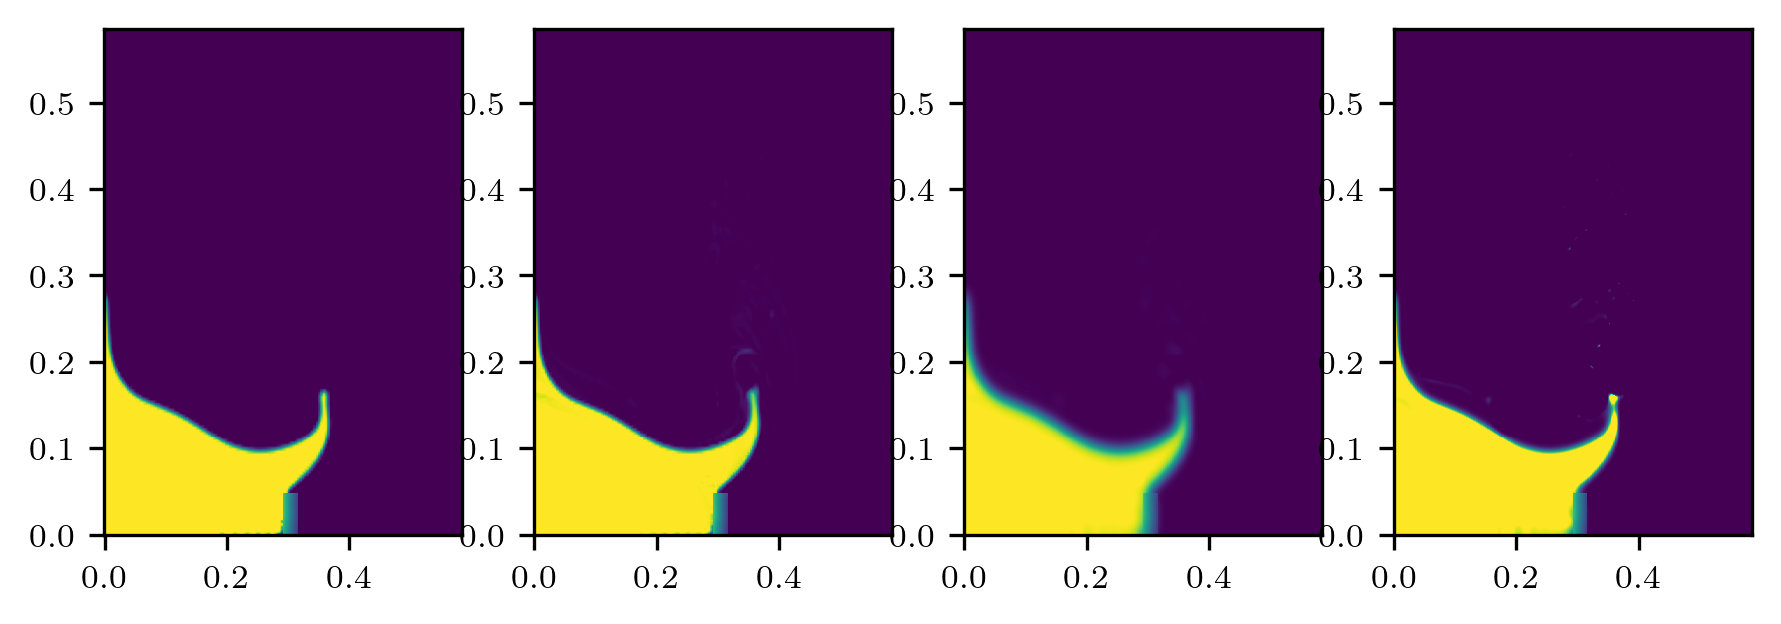

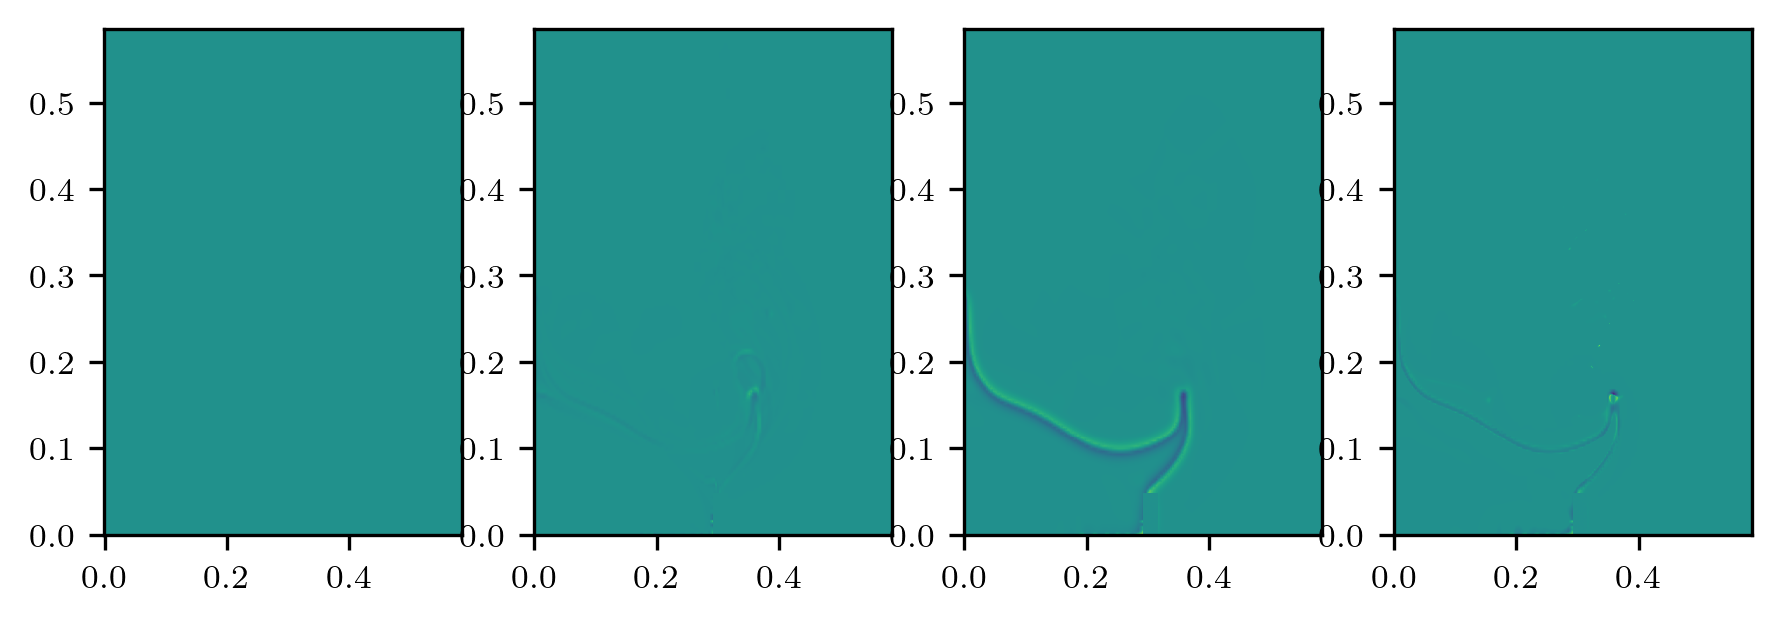

2 0.0 -0.31784271931784736 -0.026512055 0.0
2 1.0 1.2880932495564599 1.018434 1.0
2 33091.76674242553 33096.19797311423 33079.332 33077.676


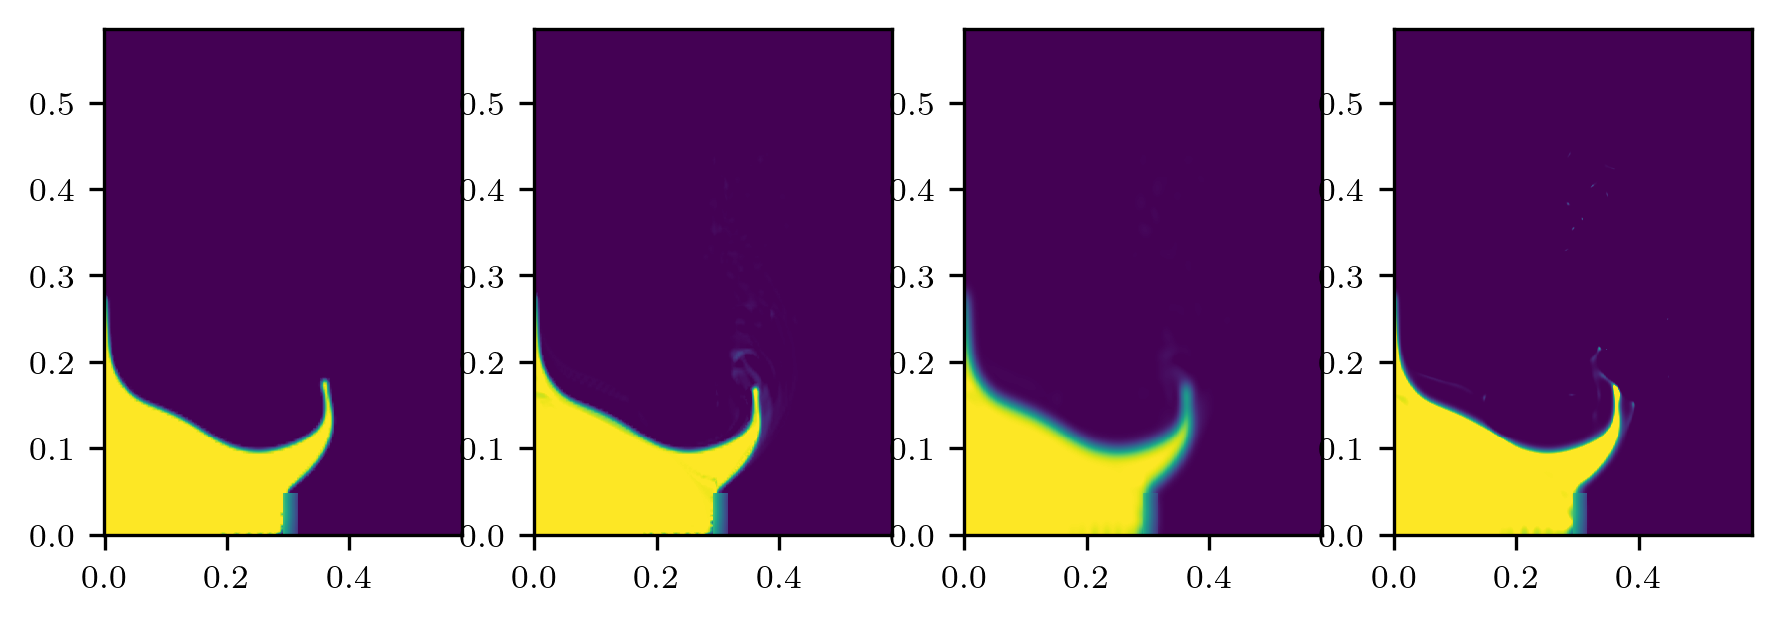

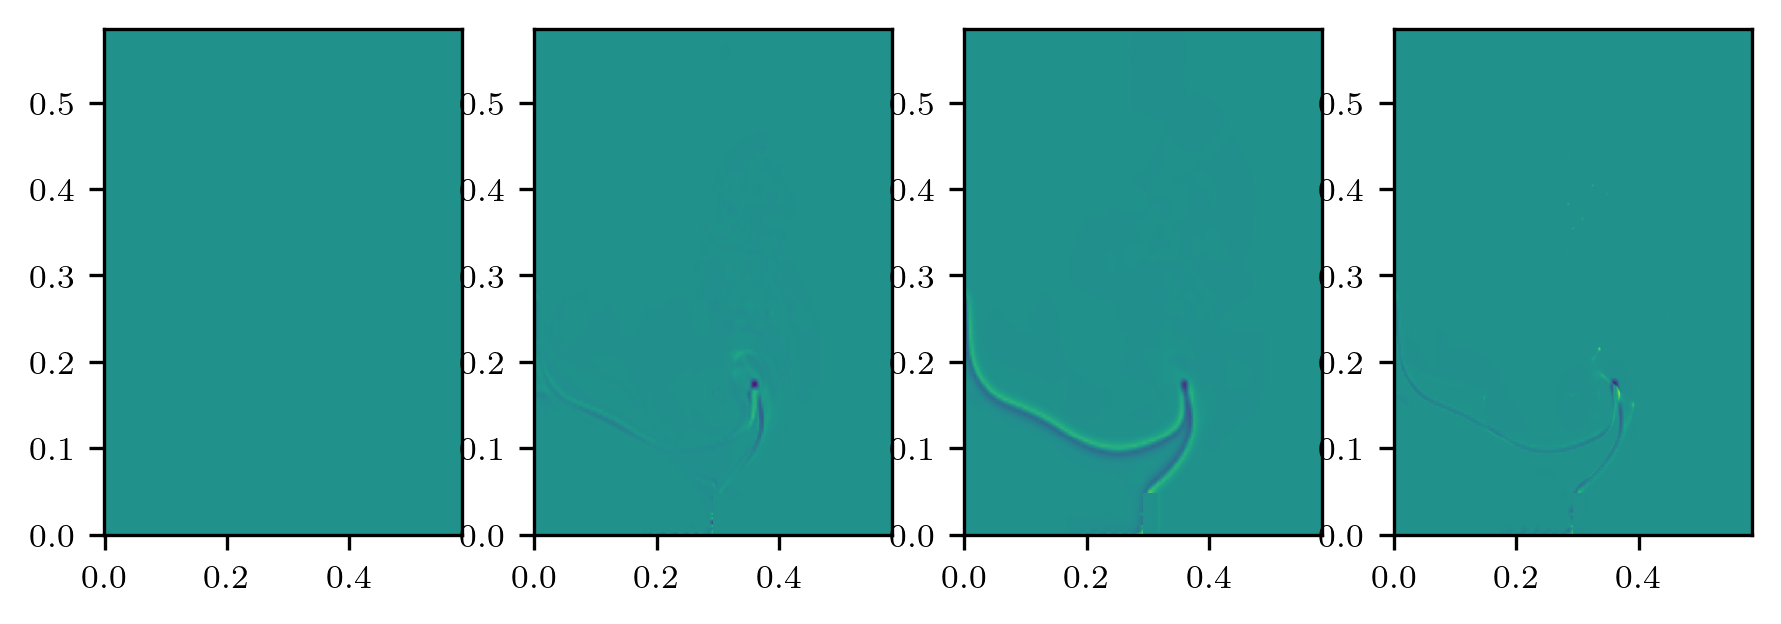

3 0.0 -0.13936631623562606 -0.04411665 0.0
3 1.0 1.2017270696457845 1.0144738 1.0
3 33054.335502977374 33057.29545469948 33055.605 33037.008


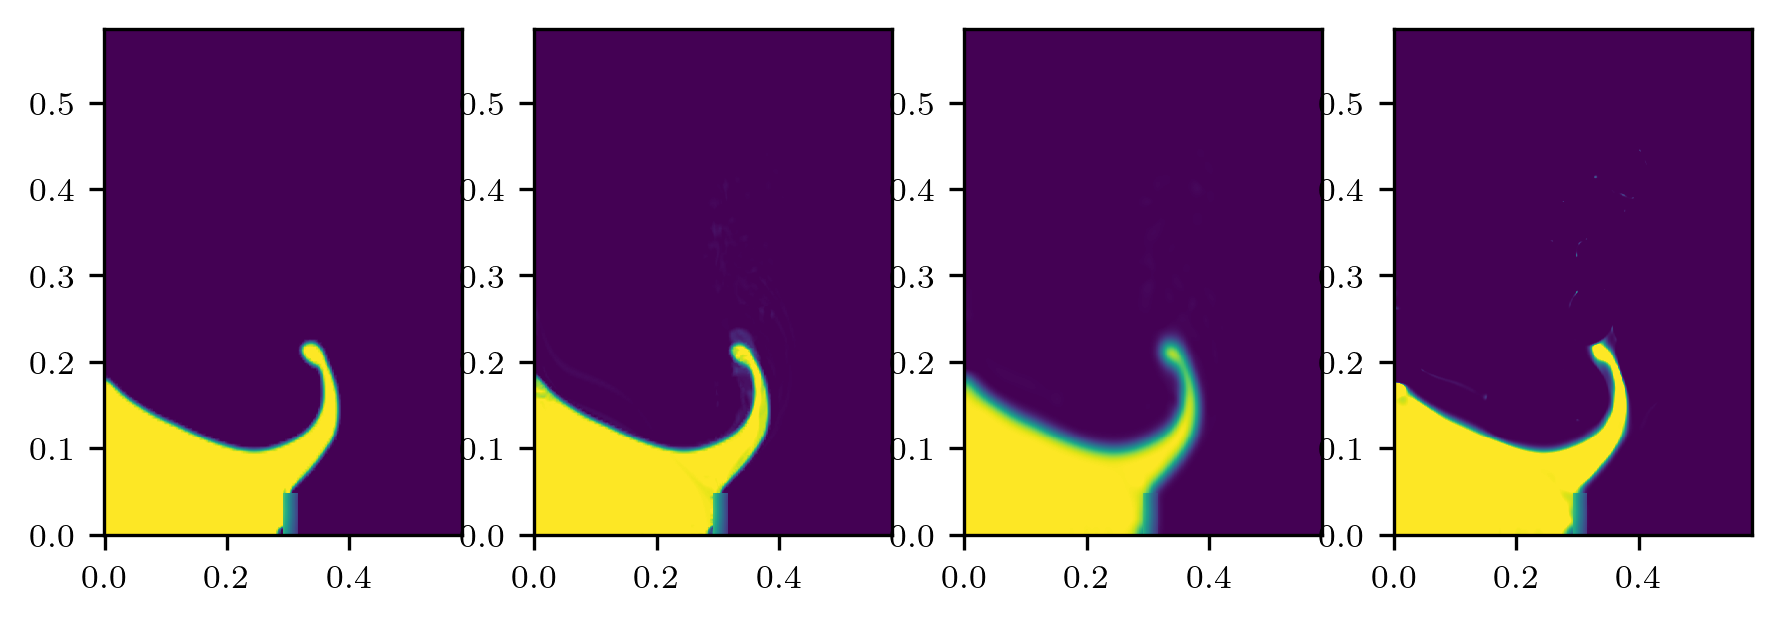

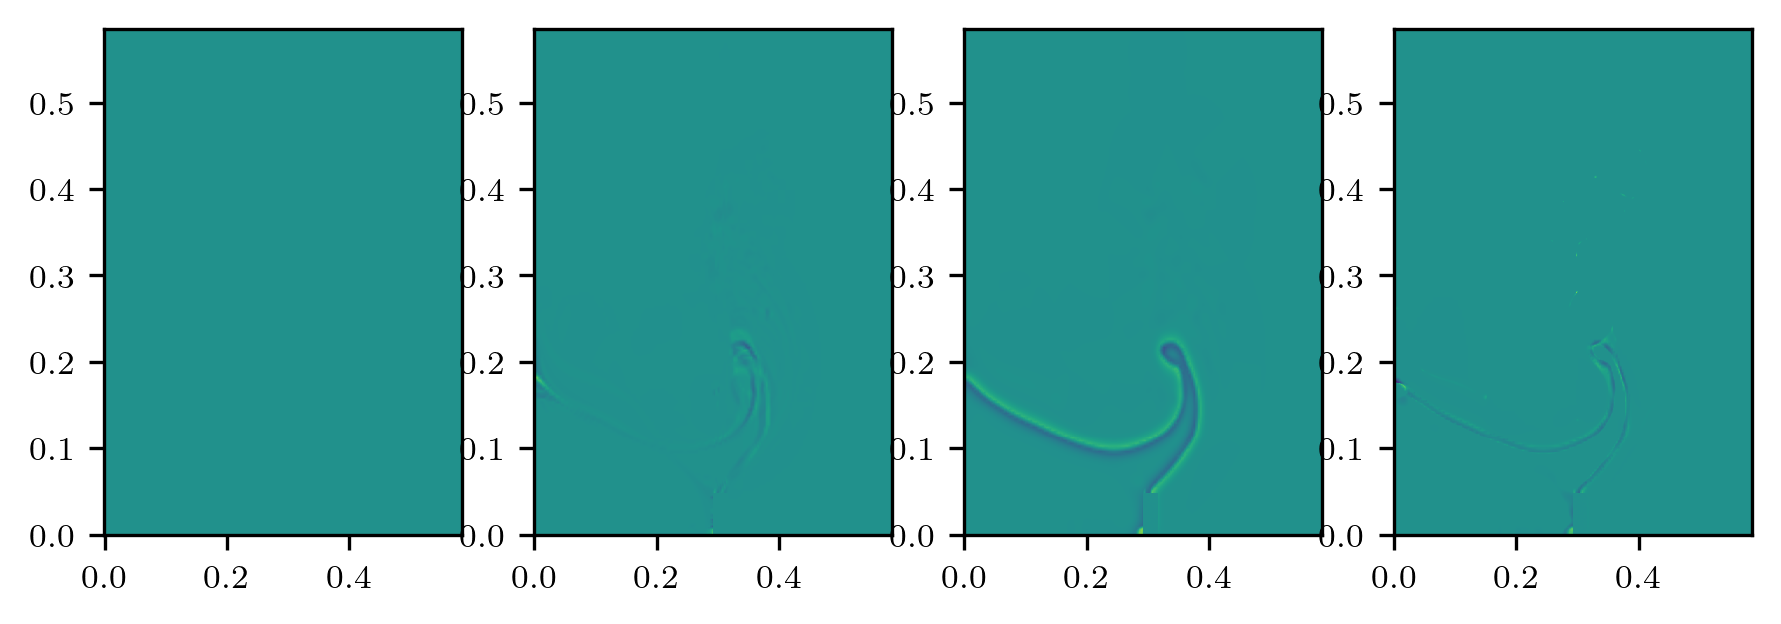

4 0.0 -0.18110679236375612 -0.040163208 0.0
4 1.0 1.1640980844537678 1.0406531 1.0
4 33091.6505581586 33101.241554907916 33076.75 33071.17


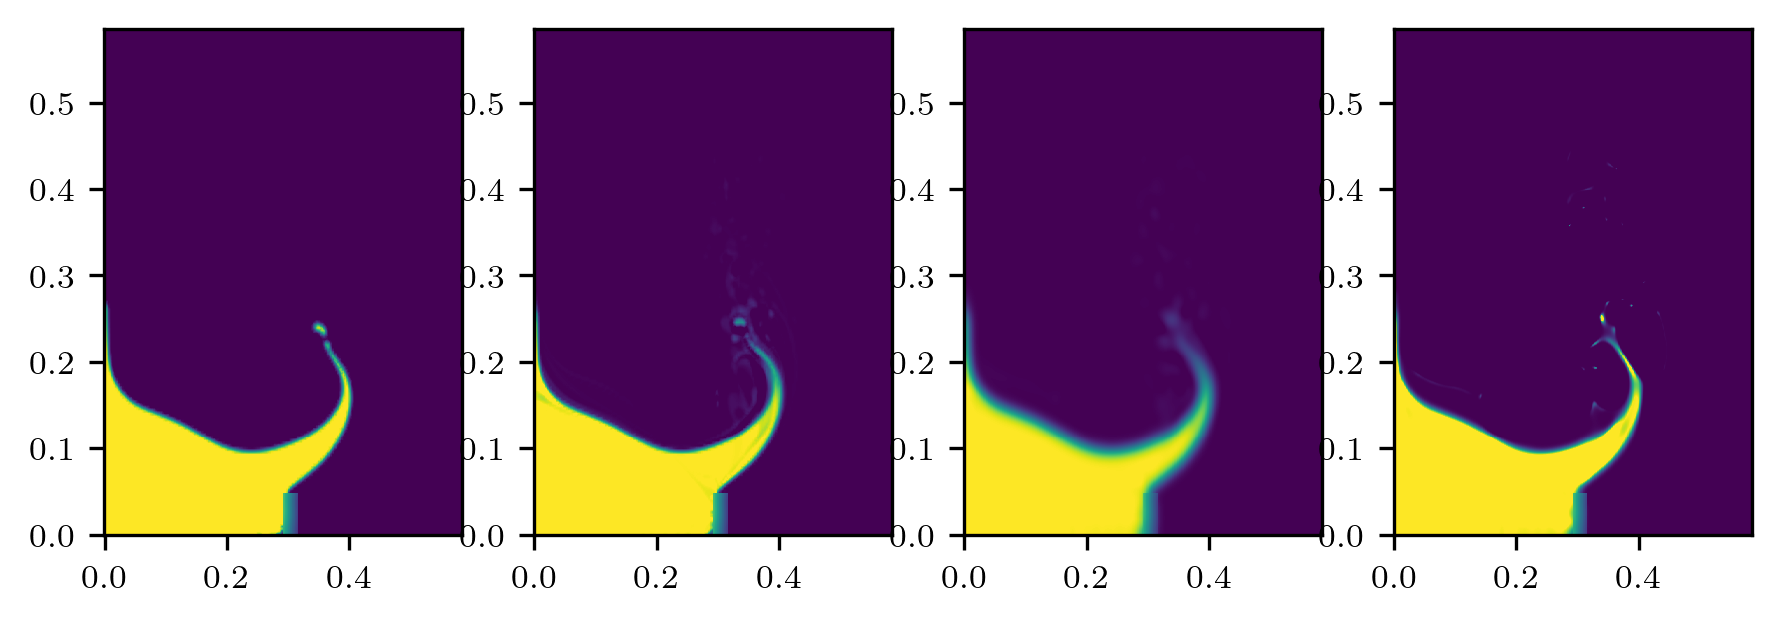

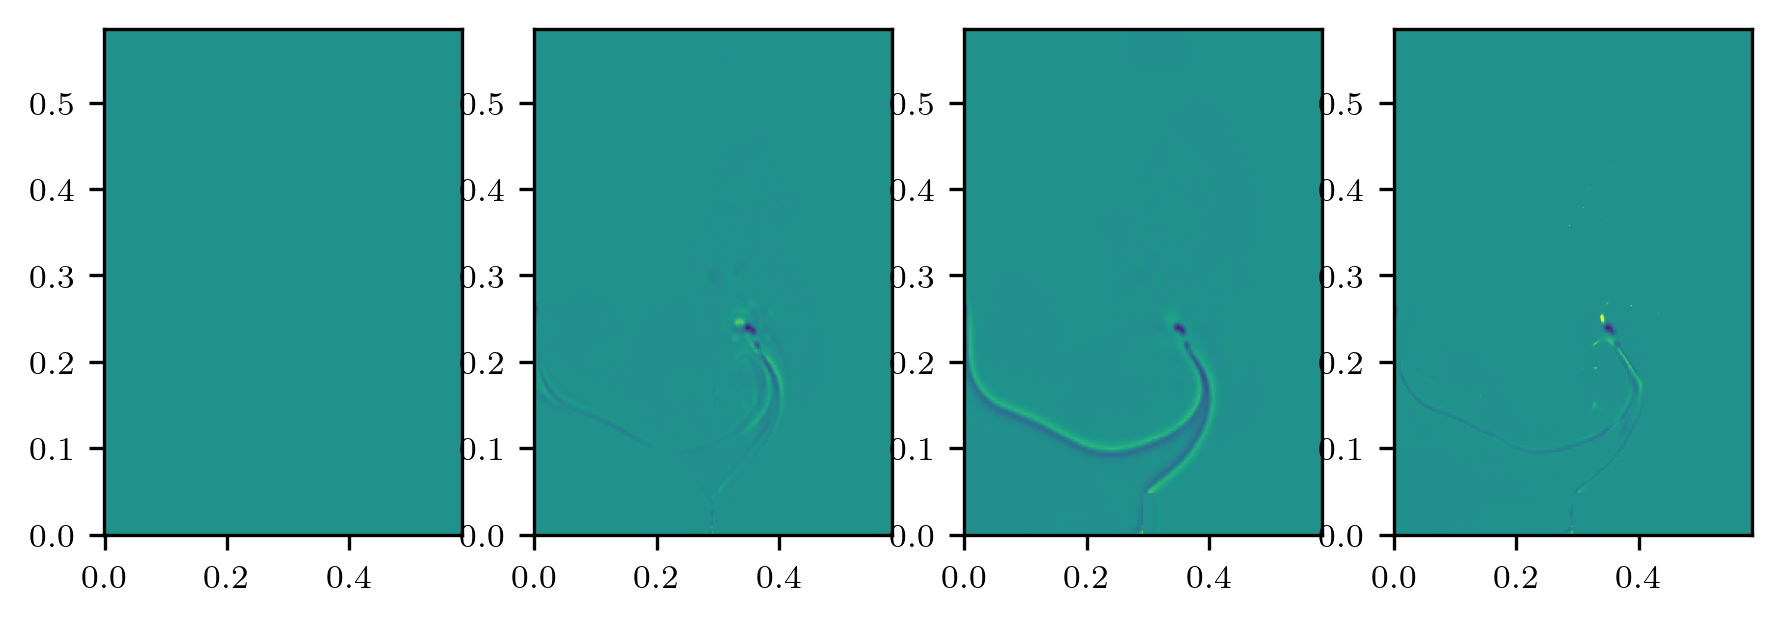

5 0.0 -0.09718589527483514 -0.029100532 0.0
5 1.0 1.177896693577475 1.0093298 1.0
5 33050.25948576069 33028.2934477812 33026.906 33014.418


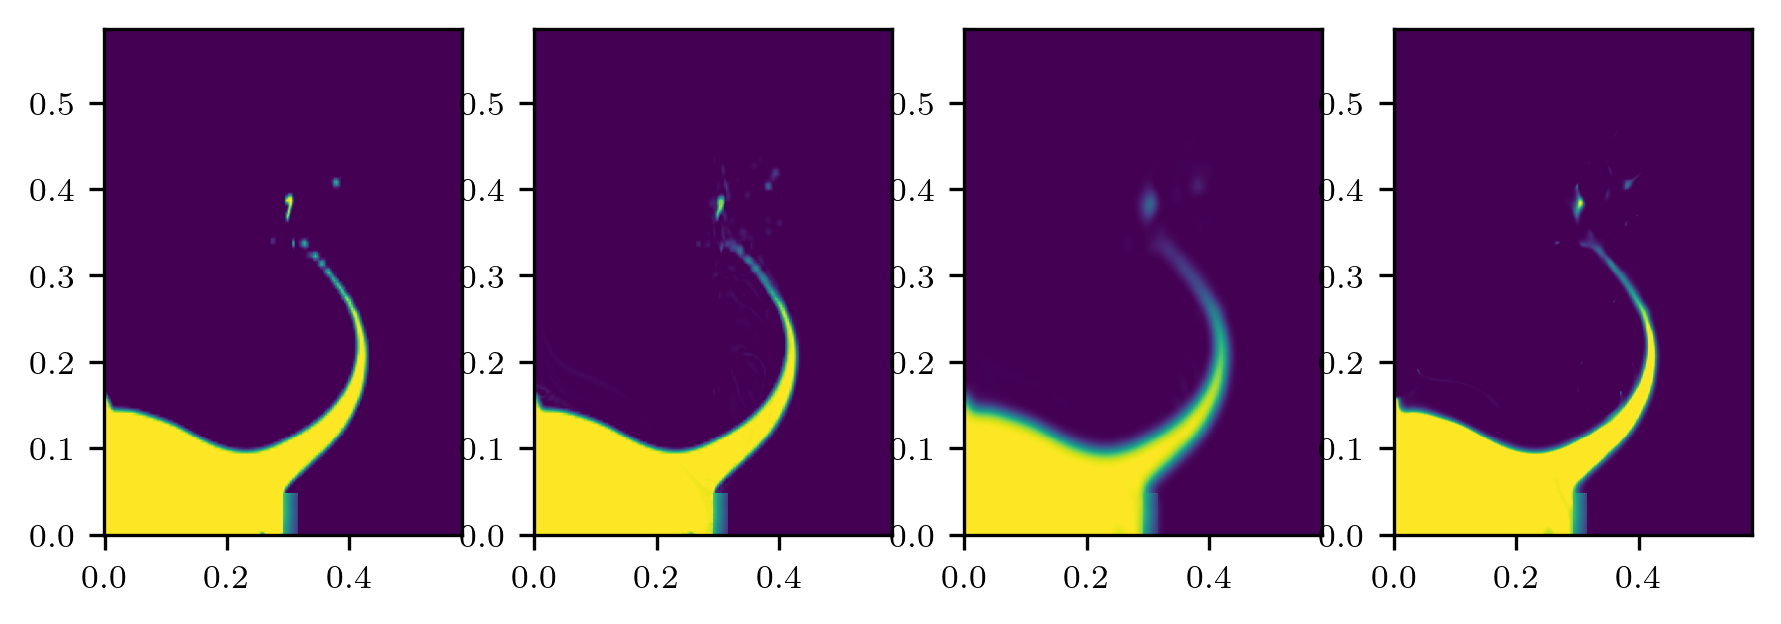

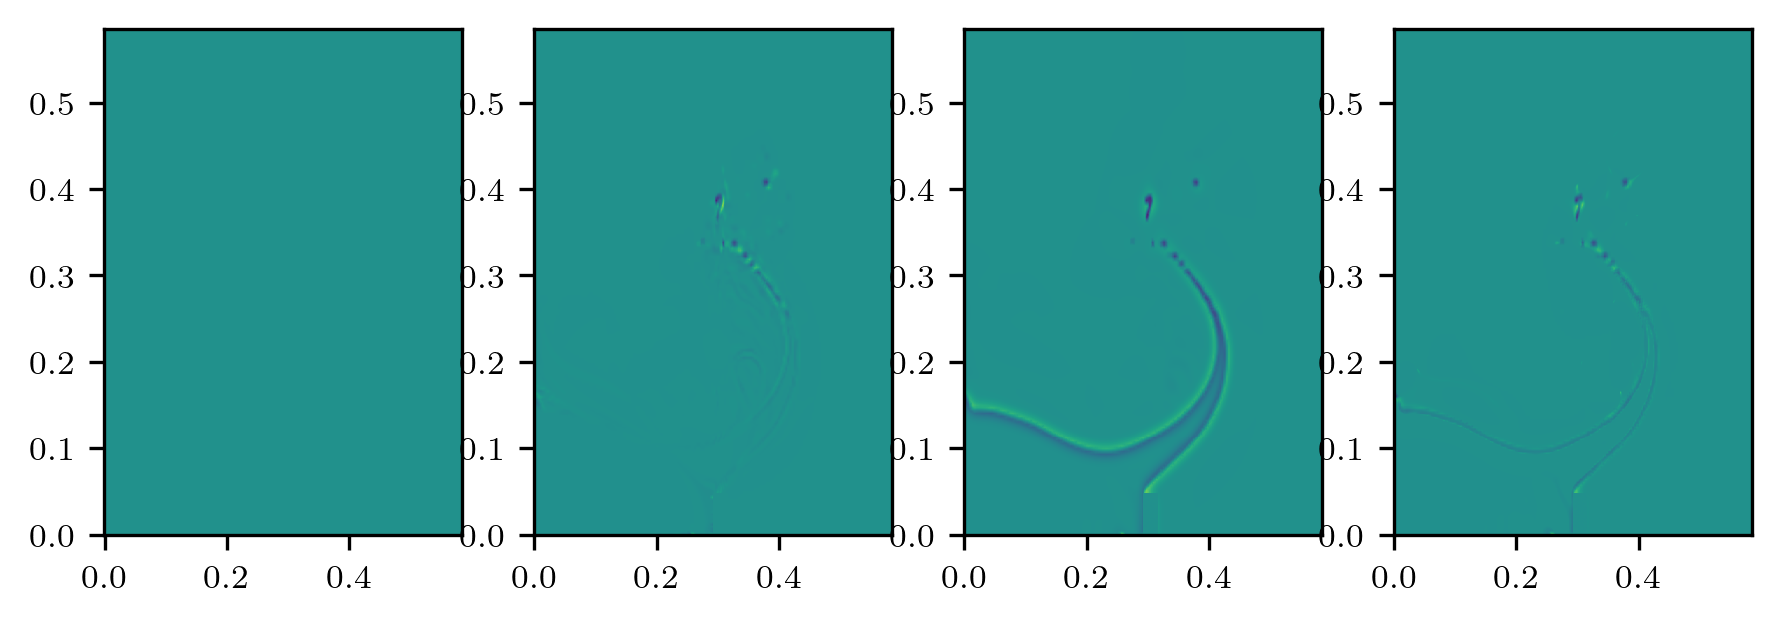

6 0.0 -0.17945060428306833 -0.039822545 0.0
6 1.0 1.2318112645401735 1.0087888 1.0
6 33057.62186038363 33031.8064296296 33028.68 33014.266


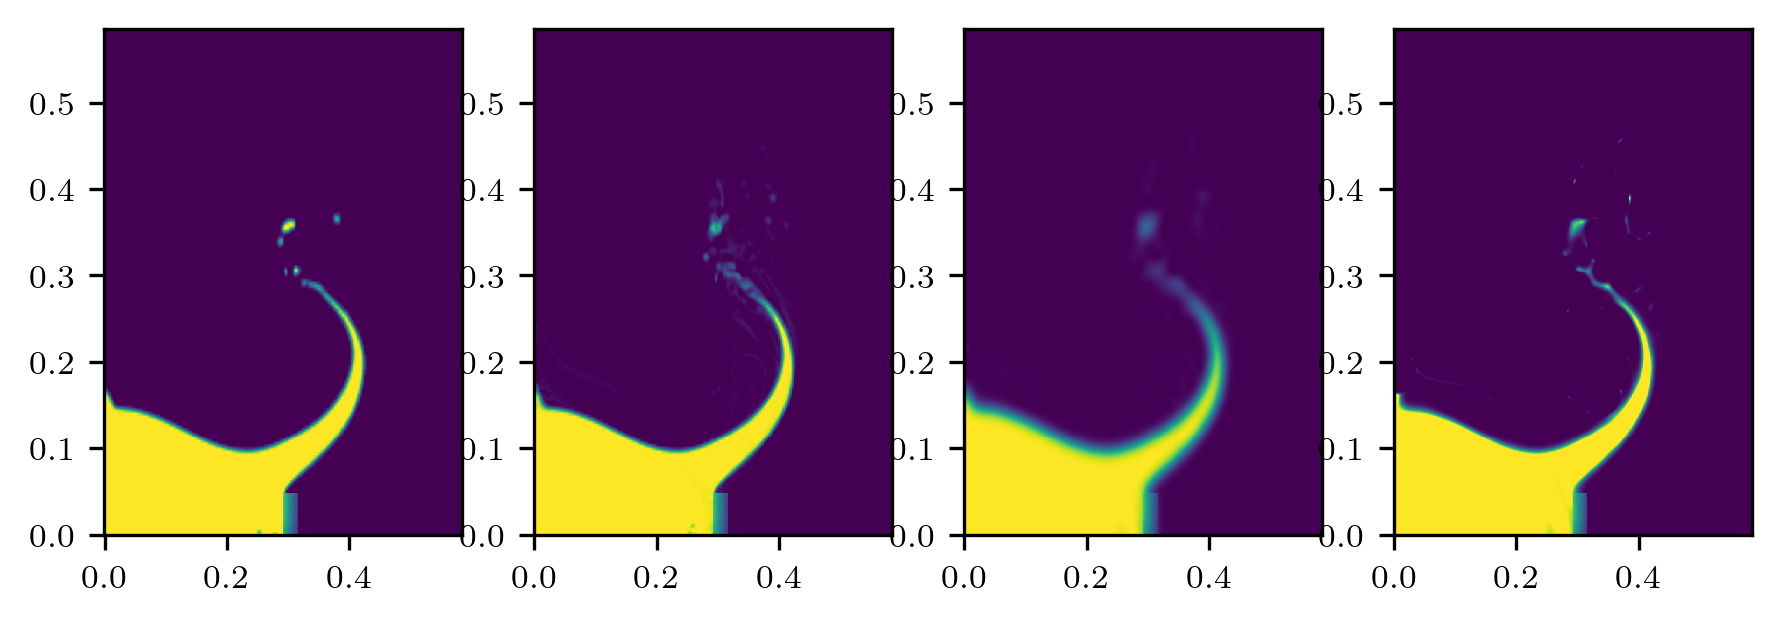

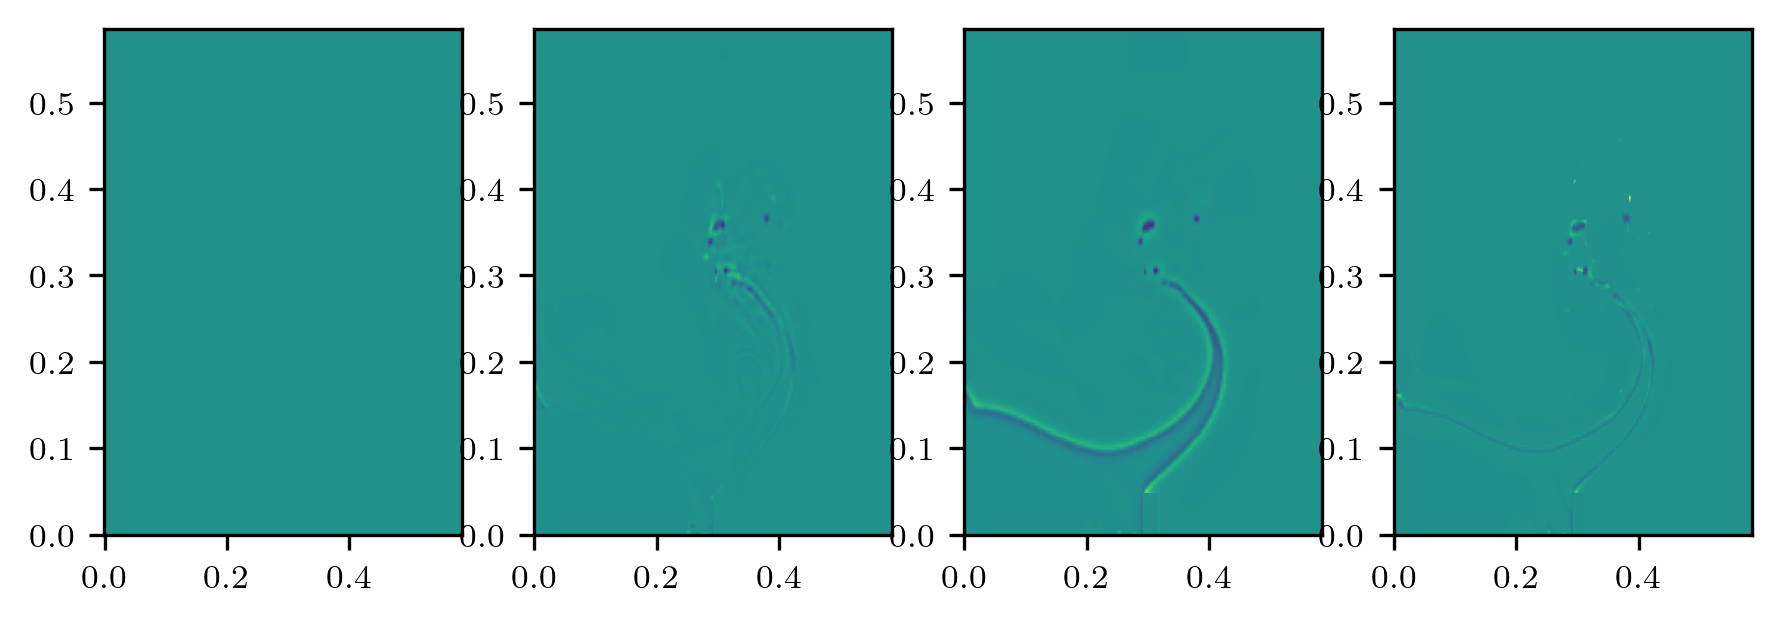

7 0.0 -0.150803575309559 -0.059691817 0.0
7 1.0 1.3084498678126446 1.0155585 1.0
7 33052.21713777645 33039.25438830051 33033.082 33025.723


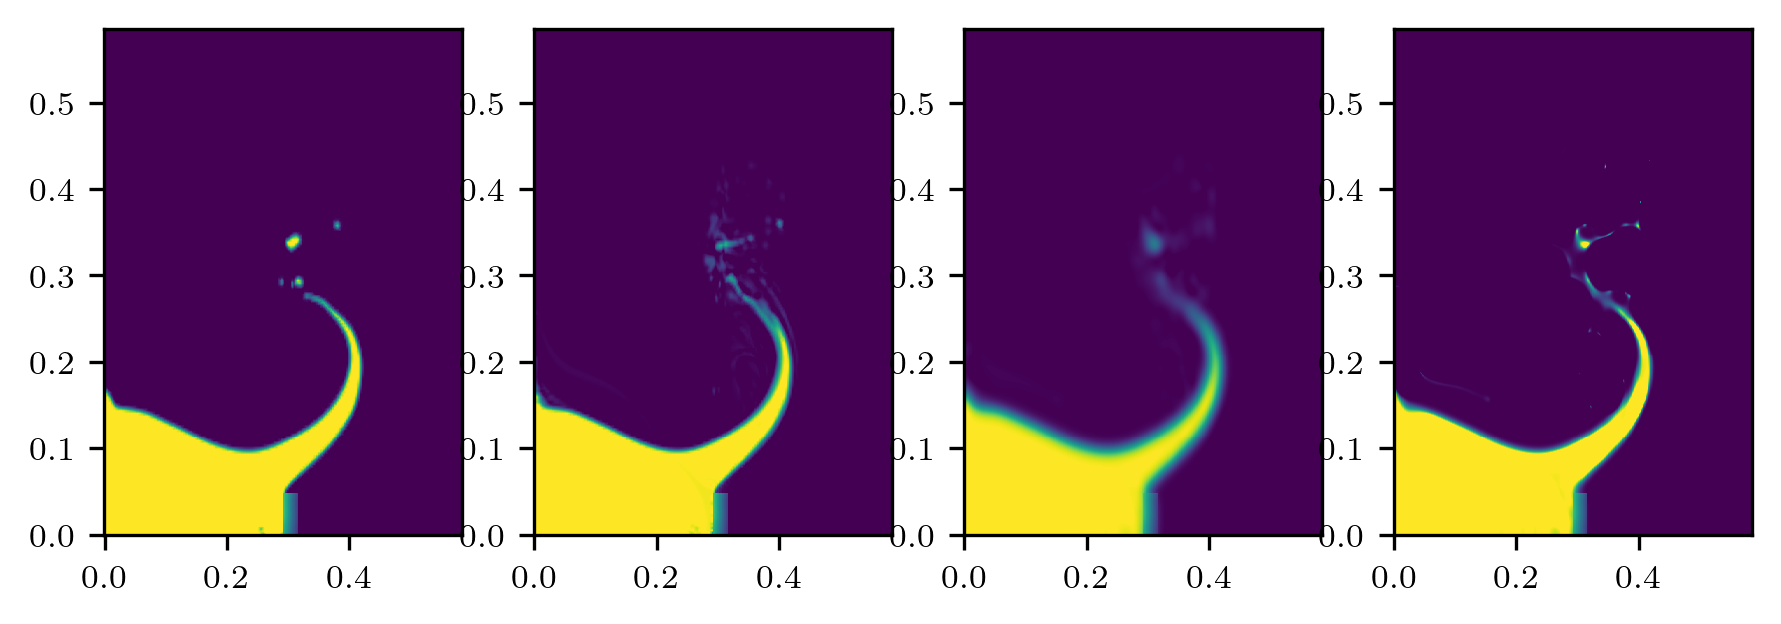

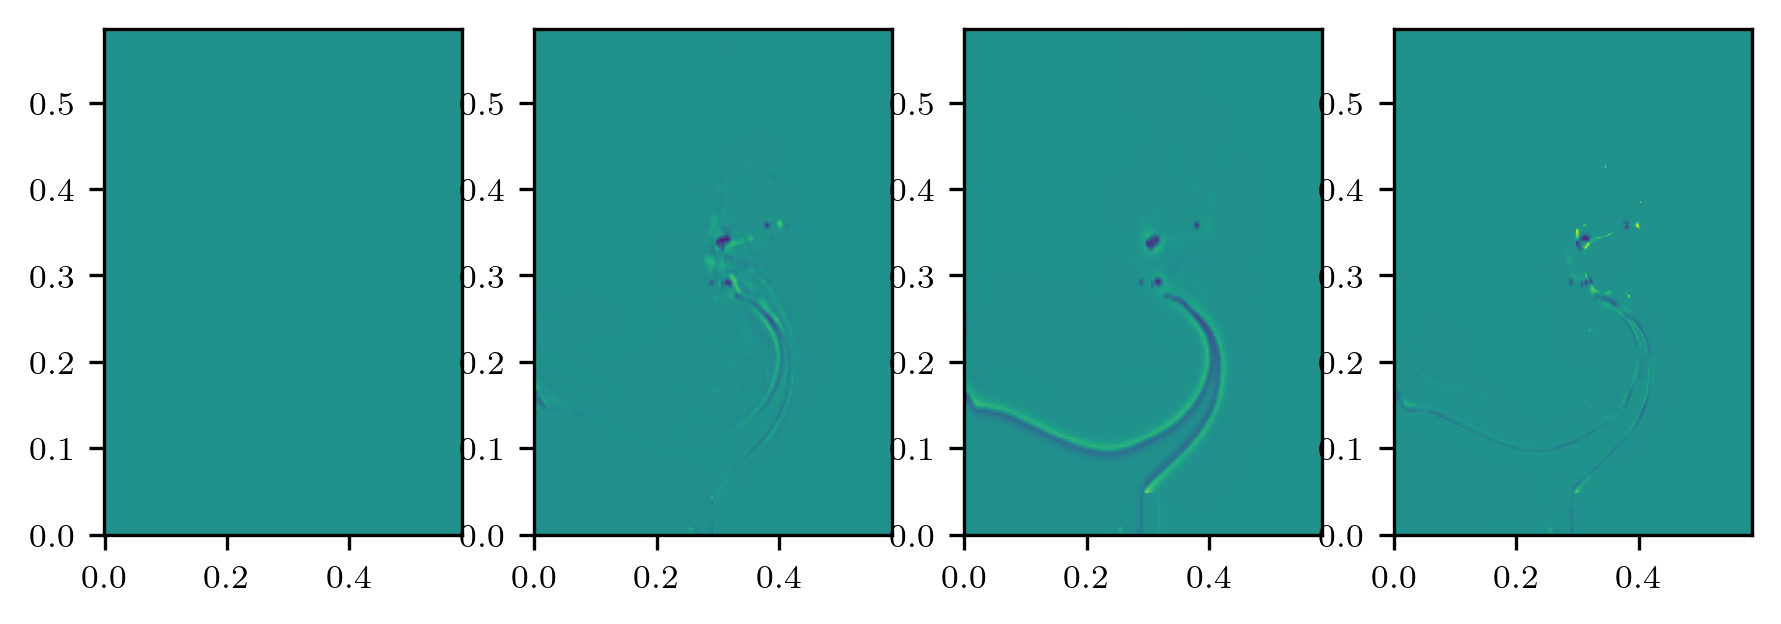

8 0.0 -0.11184727260054358 -0.046313345 0.0
8 1.0 1.5435625437094855 1.0579792 1.0
8 33089.73607930219 33099.76291022812 33081.41 33094.95


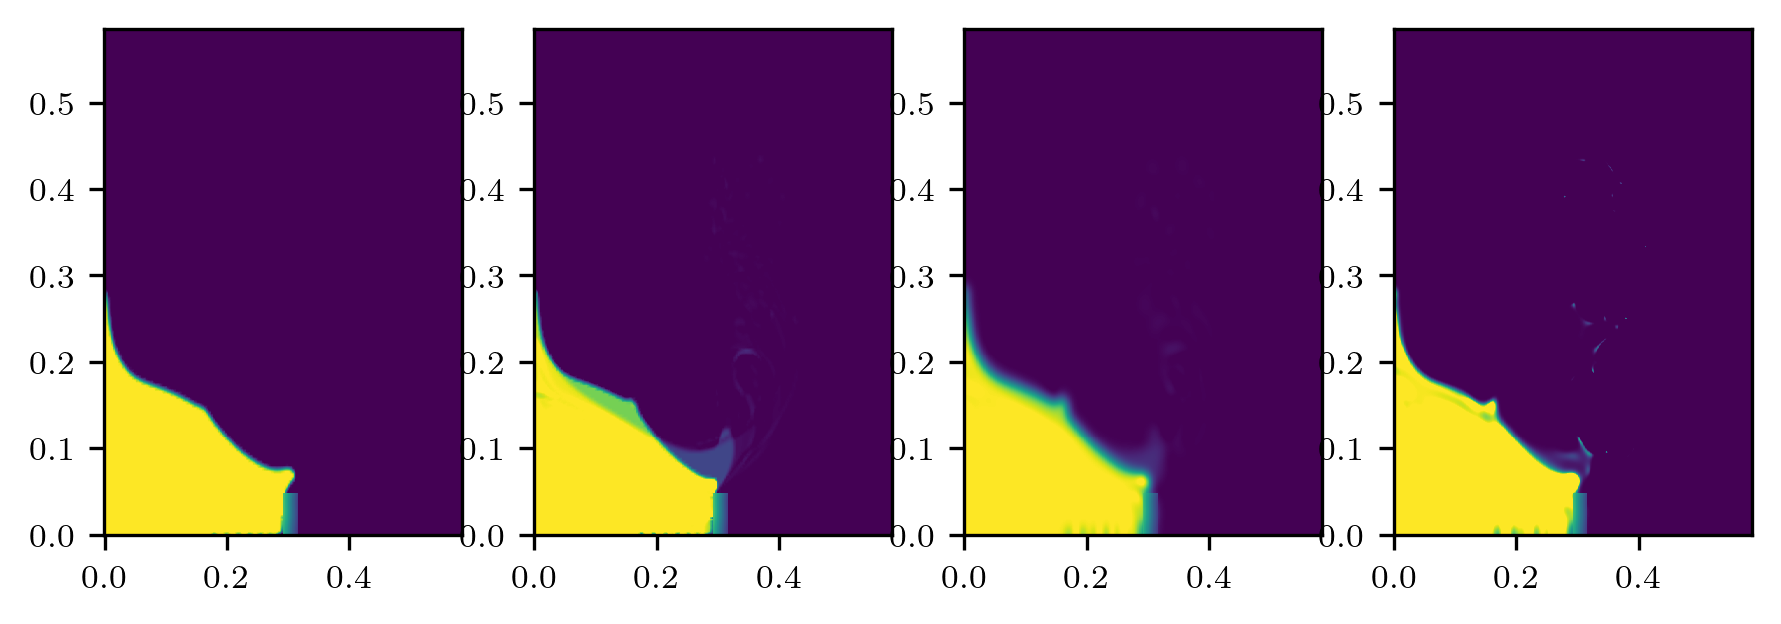

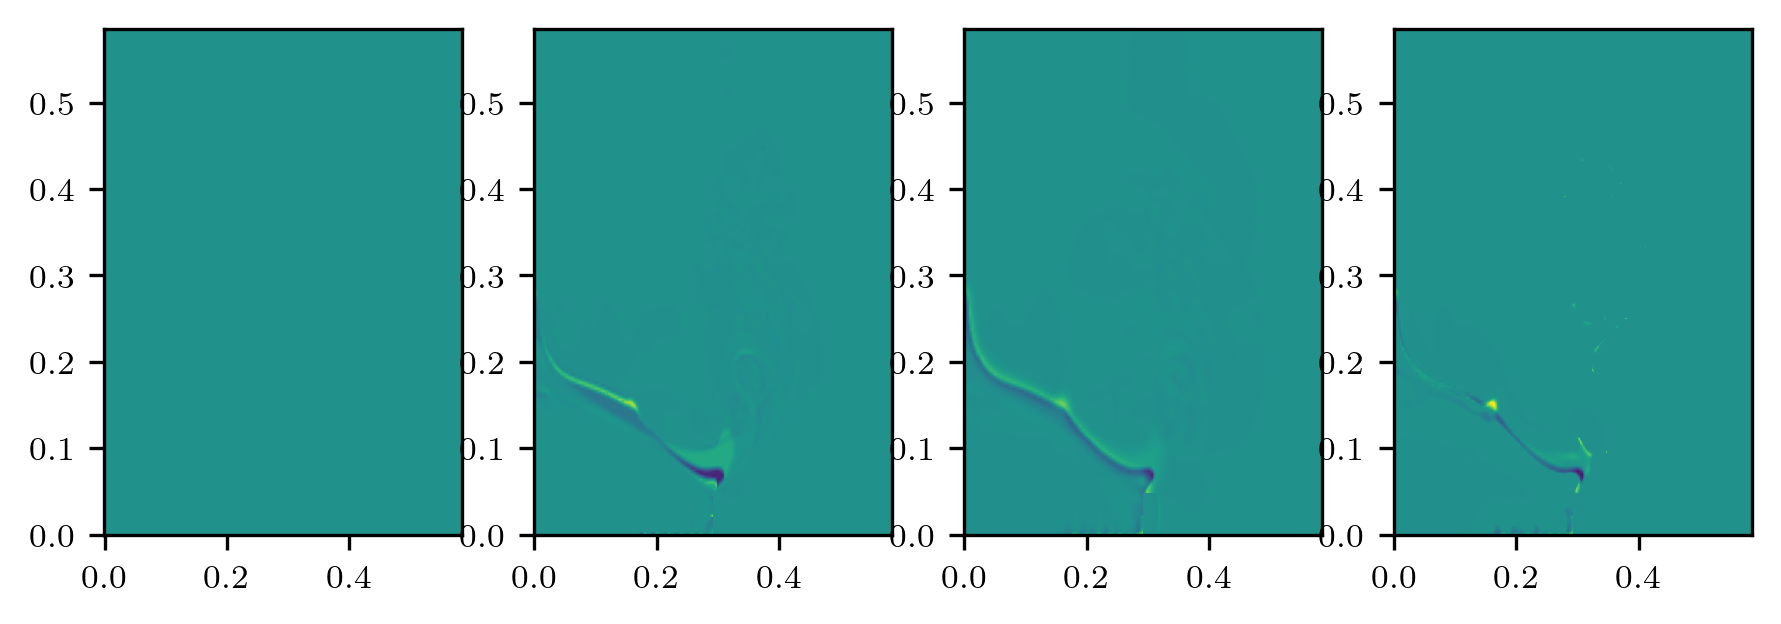

9 0.0 -0.1362487804346191 -0.031697724 0.0
9 1.0 1.1507494895161012 1.0100178 1.0
9 33042.15799839655 33013.43483136242 33020.2 33006.84


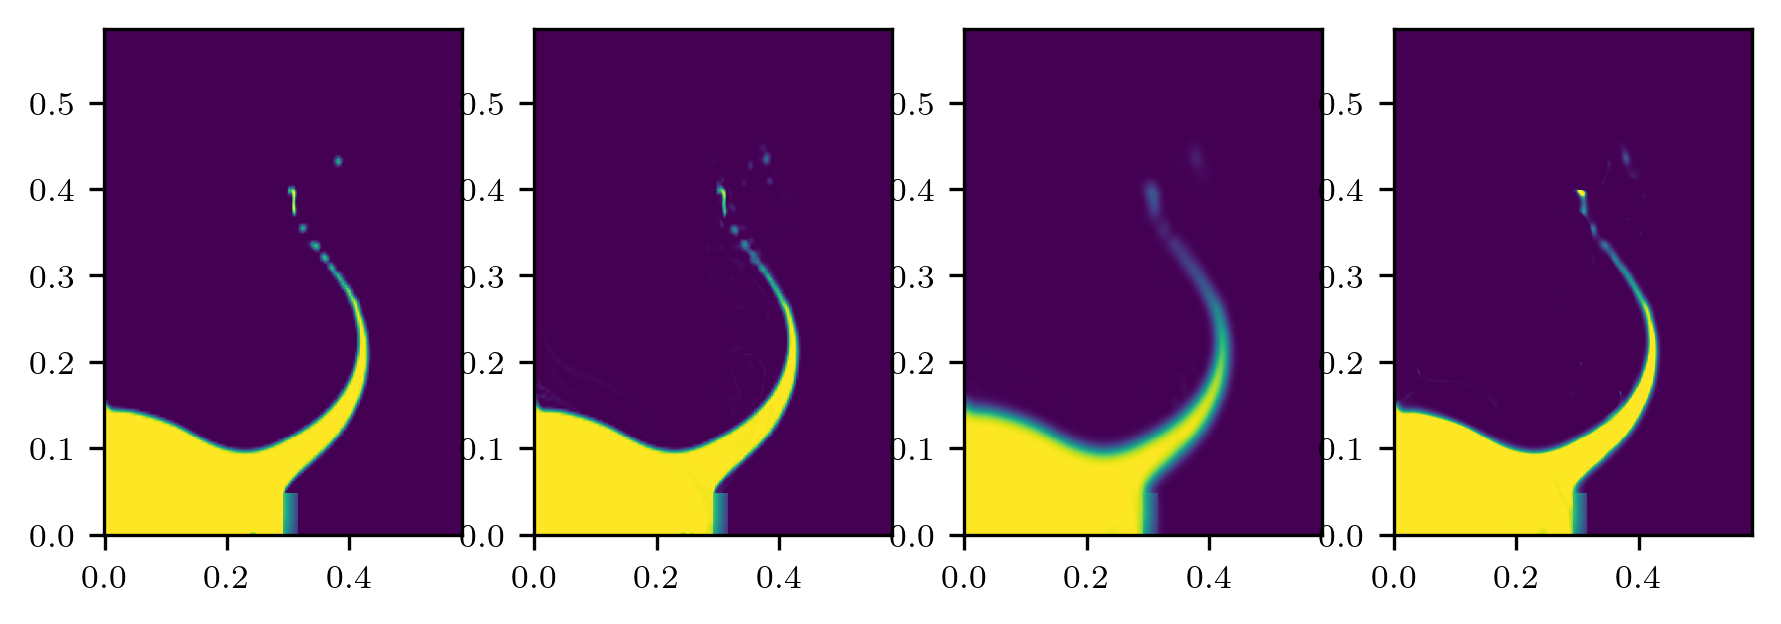

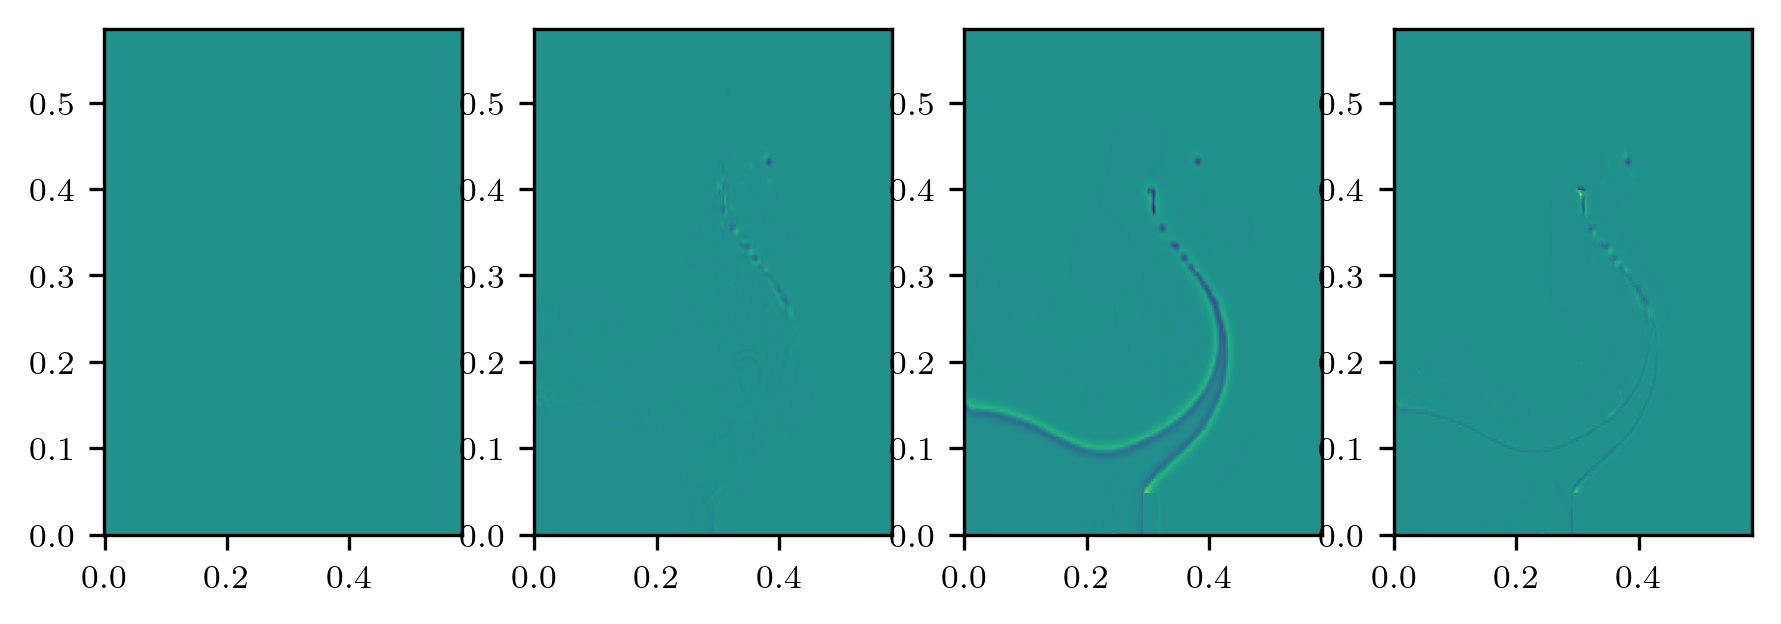

10 0.0 -0.09659458306914973 -0.028870463 0.0
10 1.0 1.1535138313747857 1.0086279 1.0
10 33050.11275854134 33016.18410993309 33020.723 33003.914


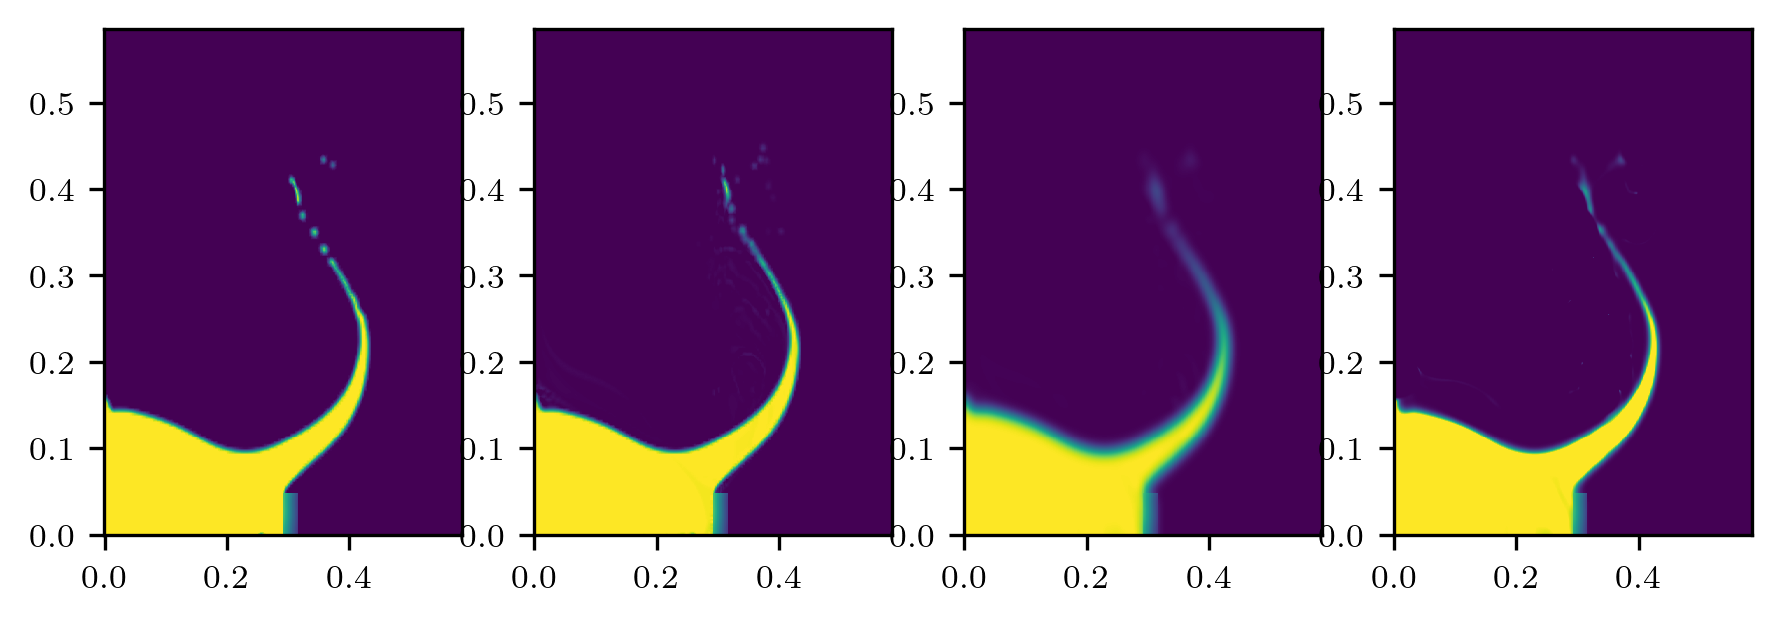

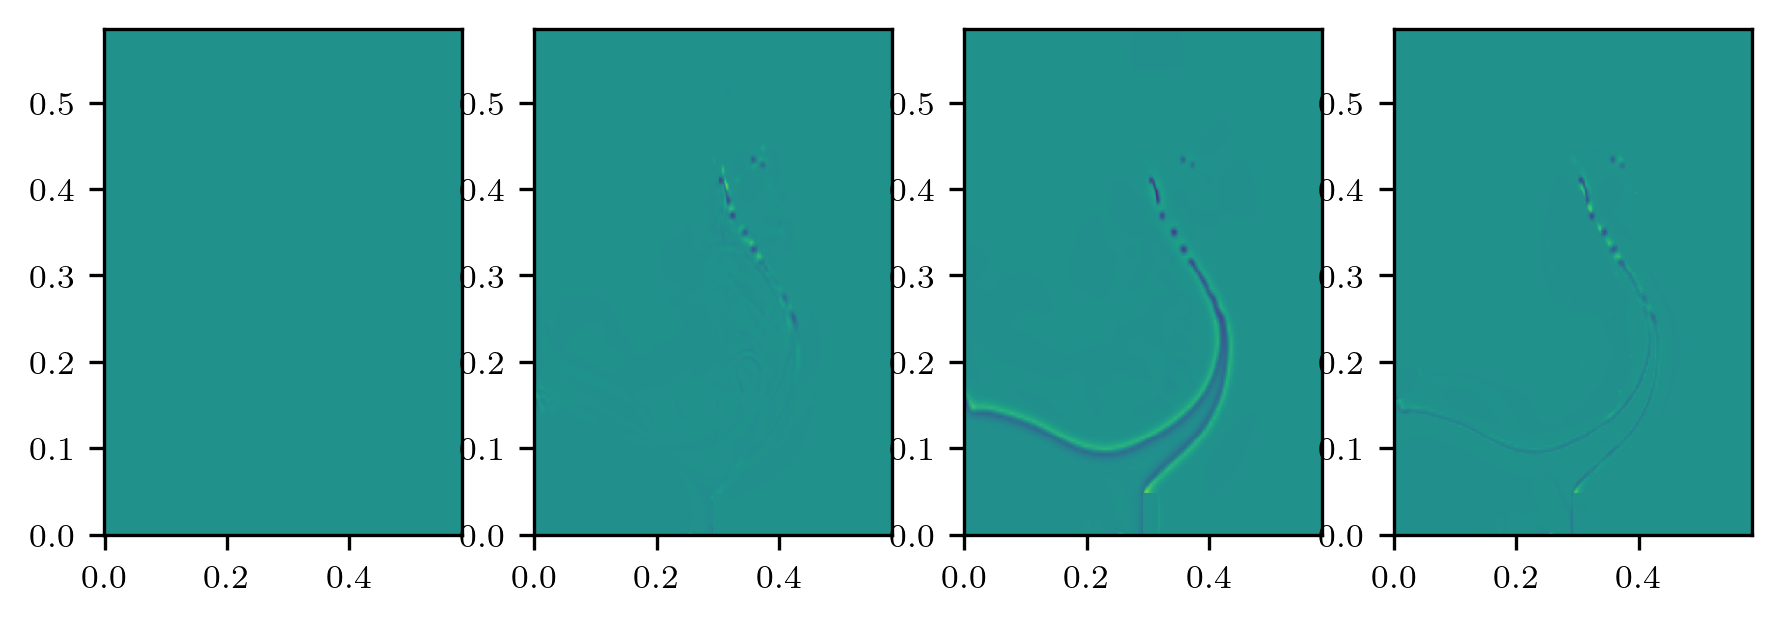

11 0.0 -0.15919570797162602 -0.049035303 0.0
11 1.0 1.1612299272274889 1.0331713 1.0
11 33094.55360757359 33109.79625191251 33079.25 33107.152


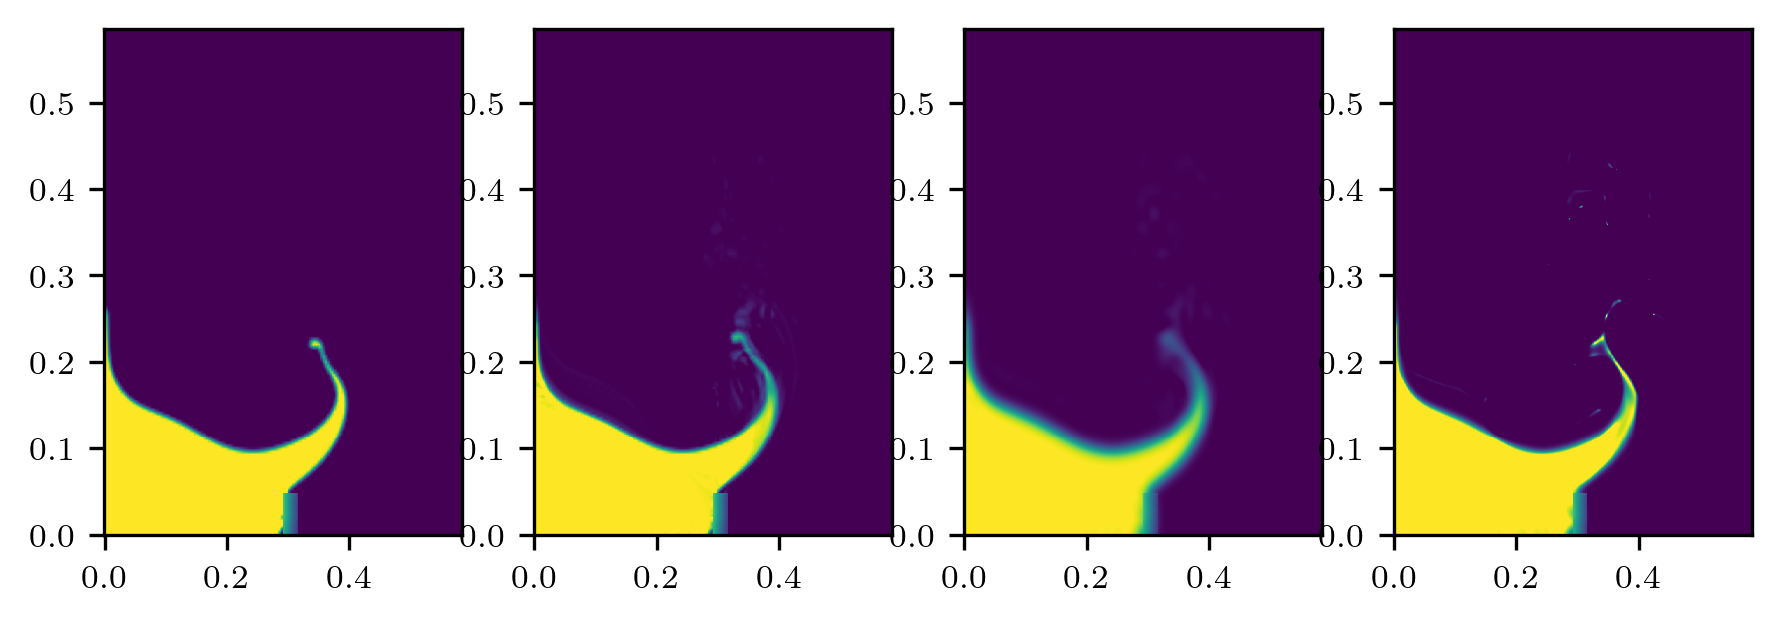

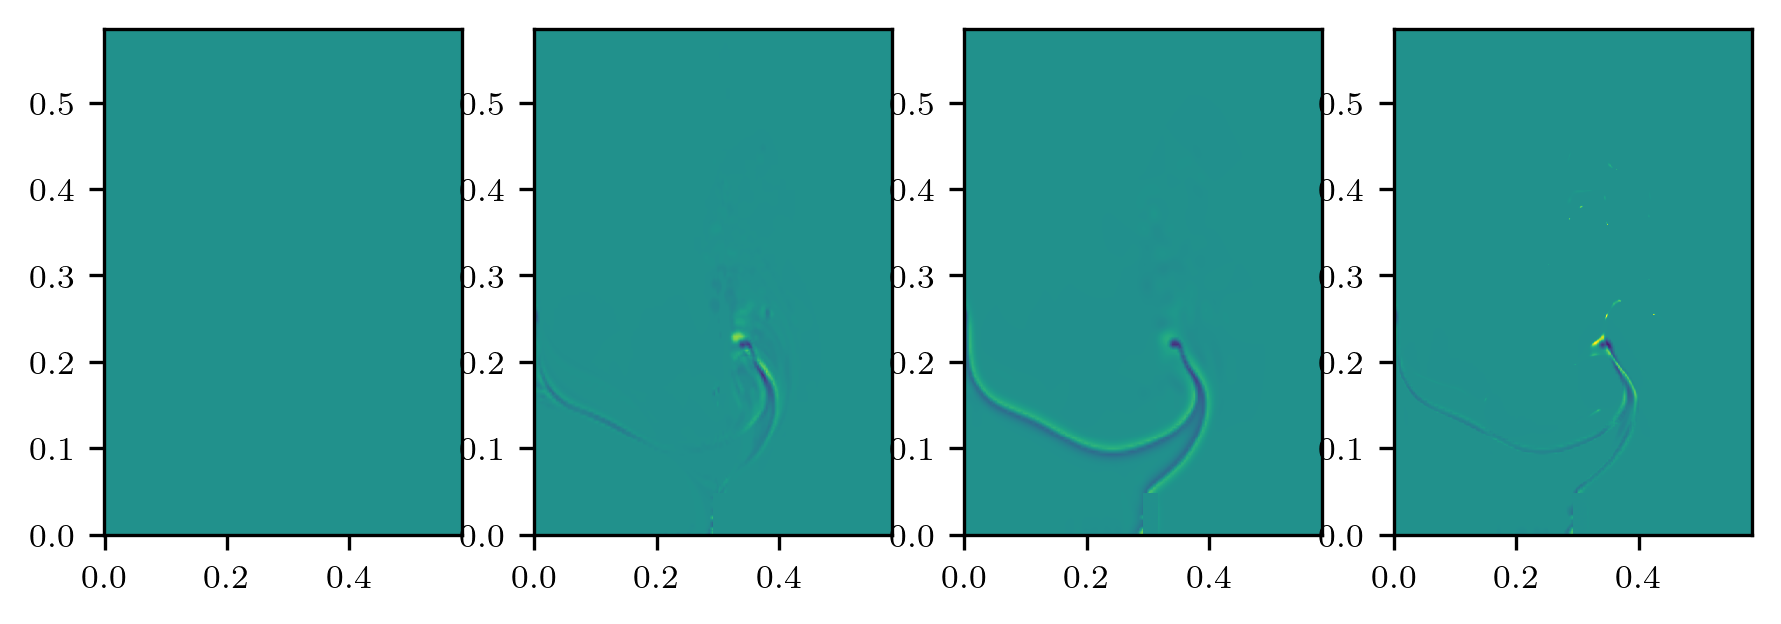

12 0.0 -0.20062827880220221 -0.049011536 0.0
12 1.0 1.3098056995574947 1.0258108 1.0
12 33052.80595438134 33073.06438276185 33042.066 33000.625


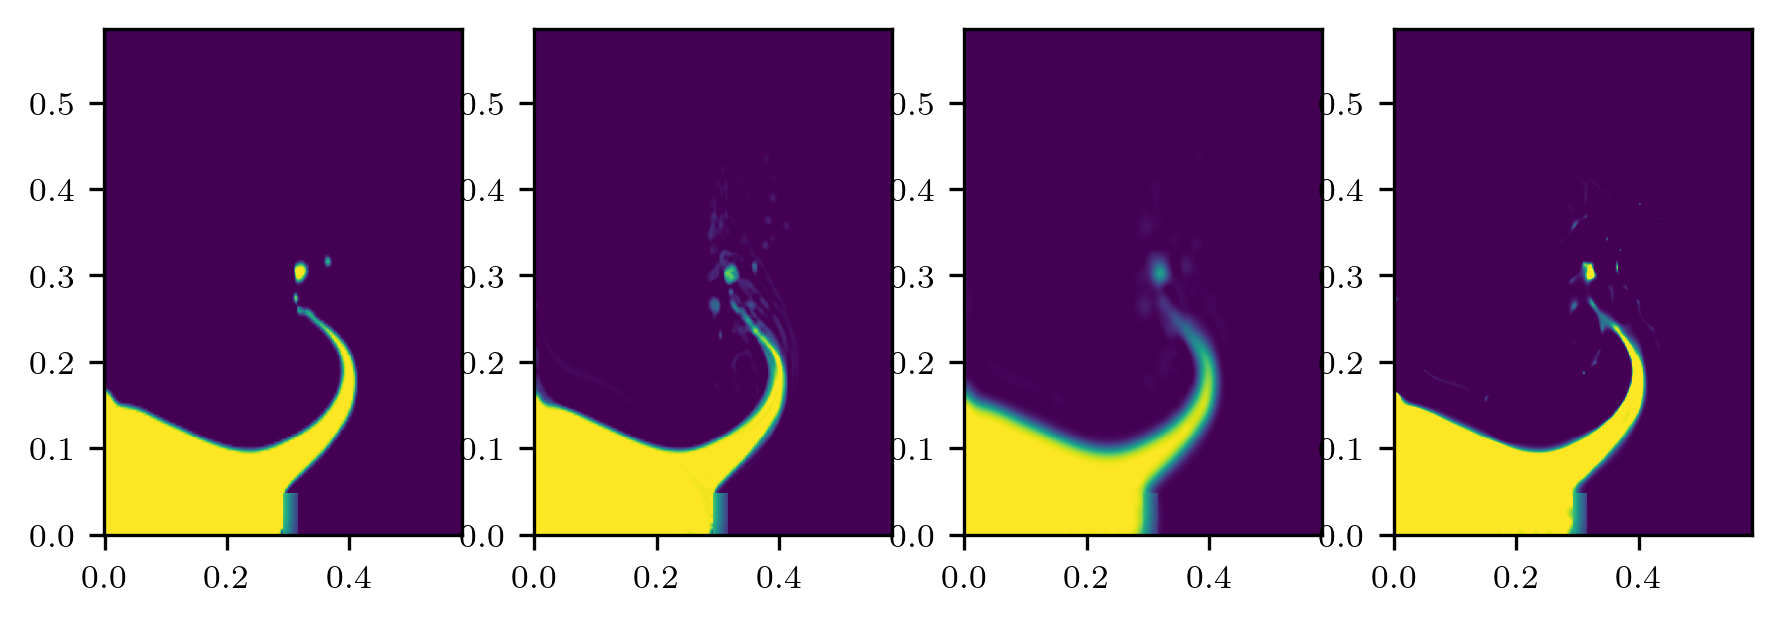

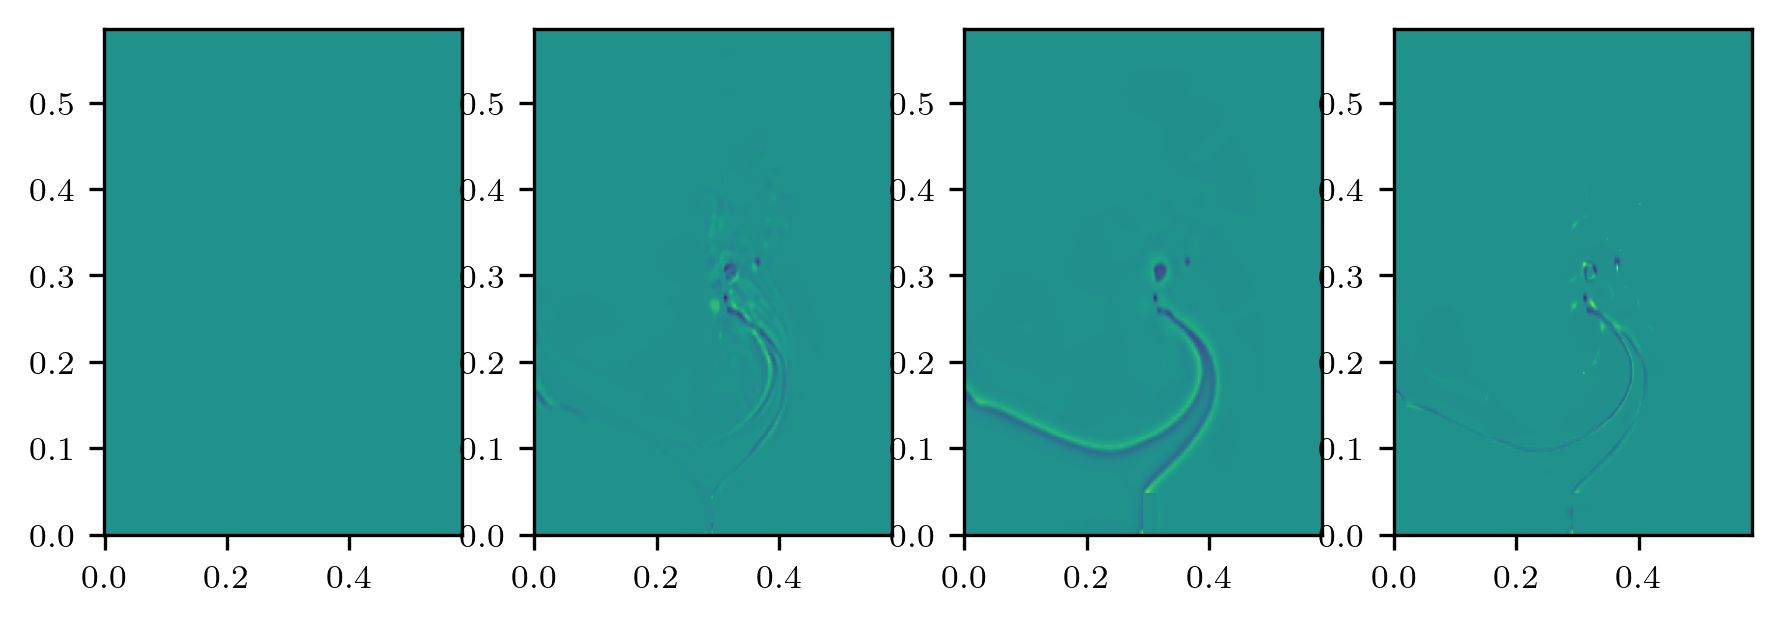

13 0.0 -0.15199409447586348 -0.043145284 0.0
13 1.0 1.1532816125800347 1.0099584 1.0
13 33070.0699378208 33029.51364224172 33044.977 33040.207


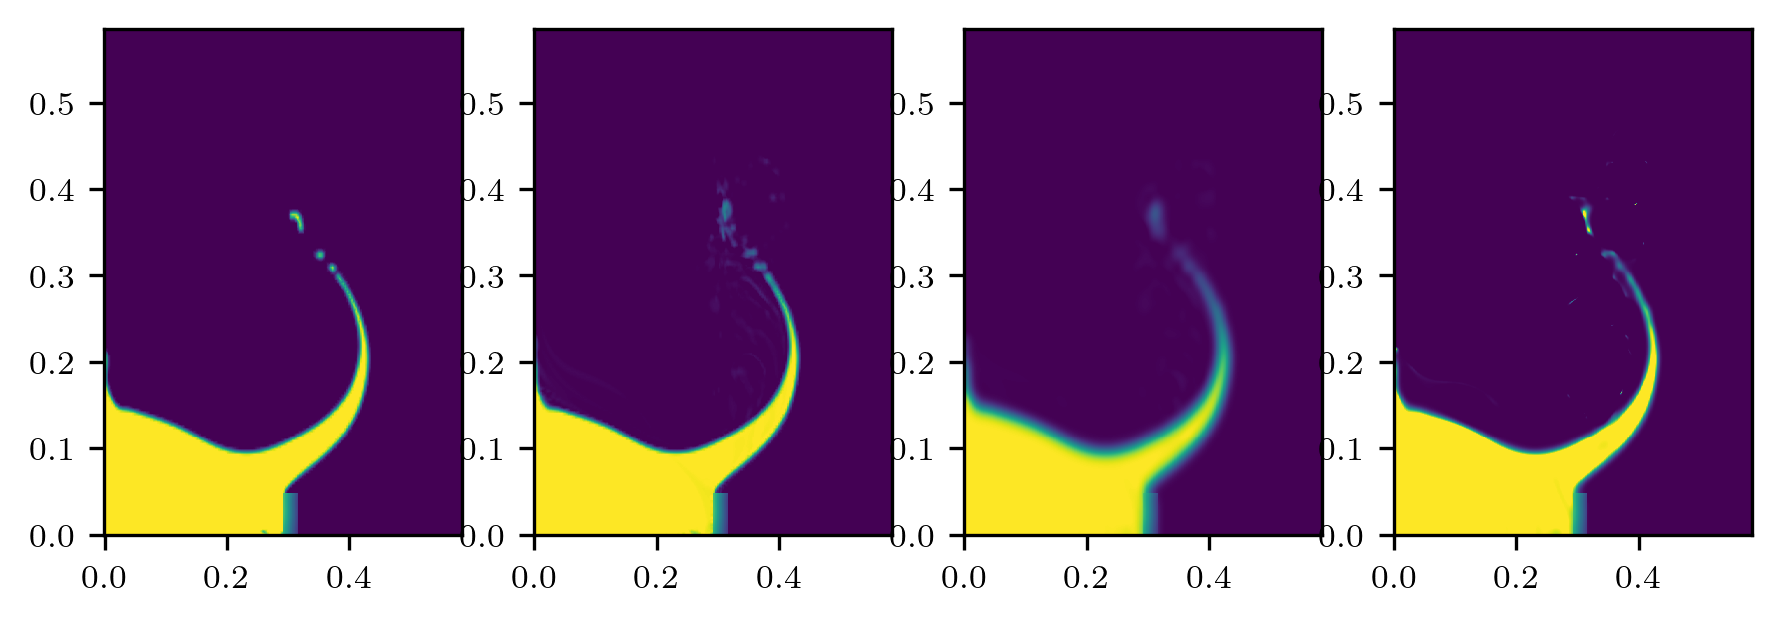

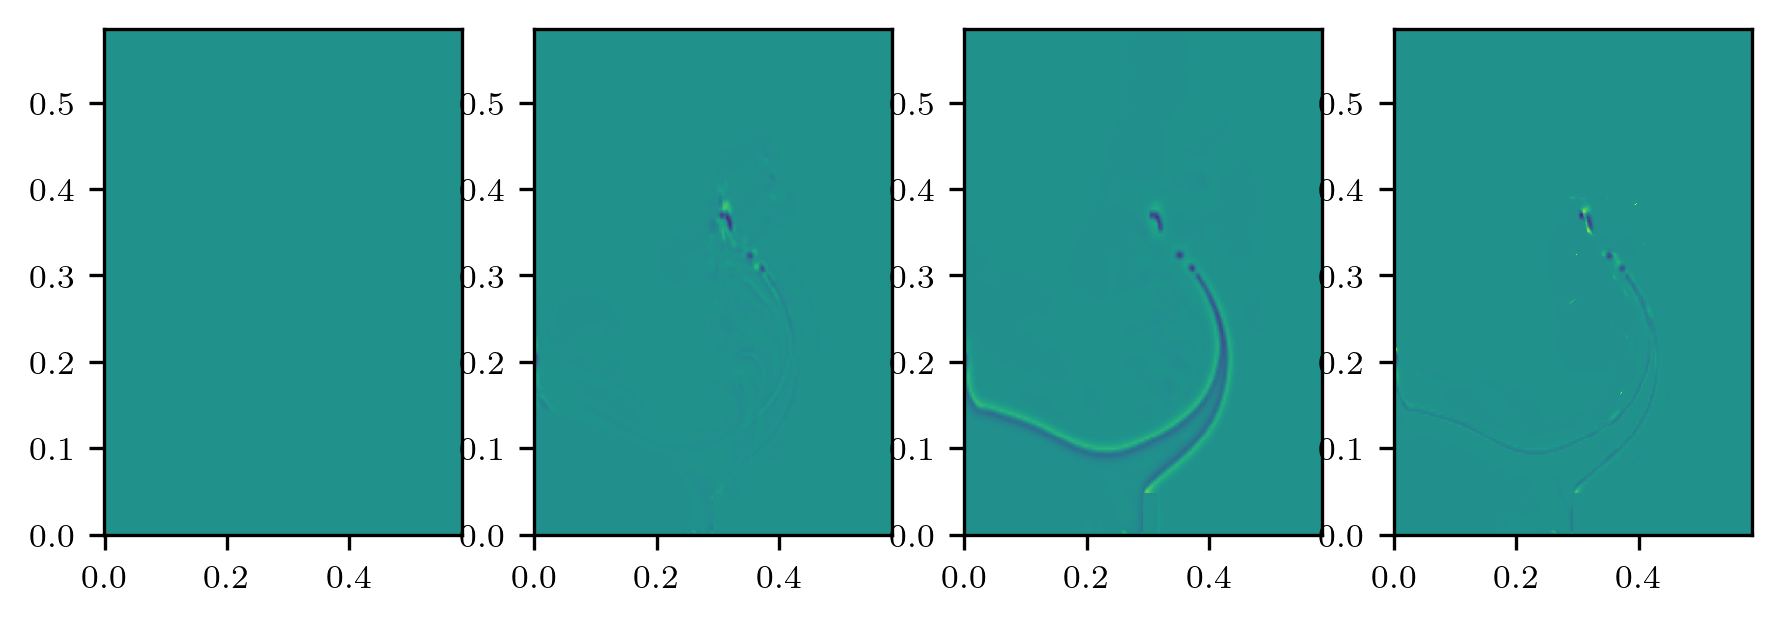

14 0.0 -0.16165619458479535 -0.039473064 0.0
14 1.0 1.278408398998614 1.0183971 1.0
14 33055.365526946785 33053.50801641396 33047.1 33038.24


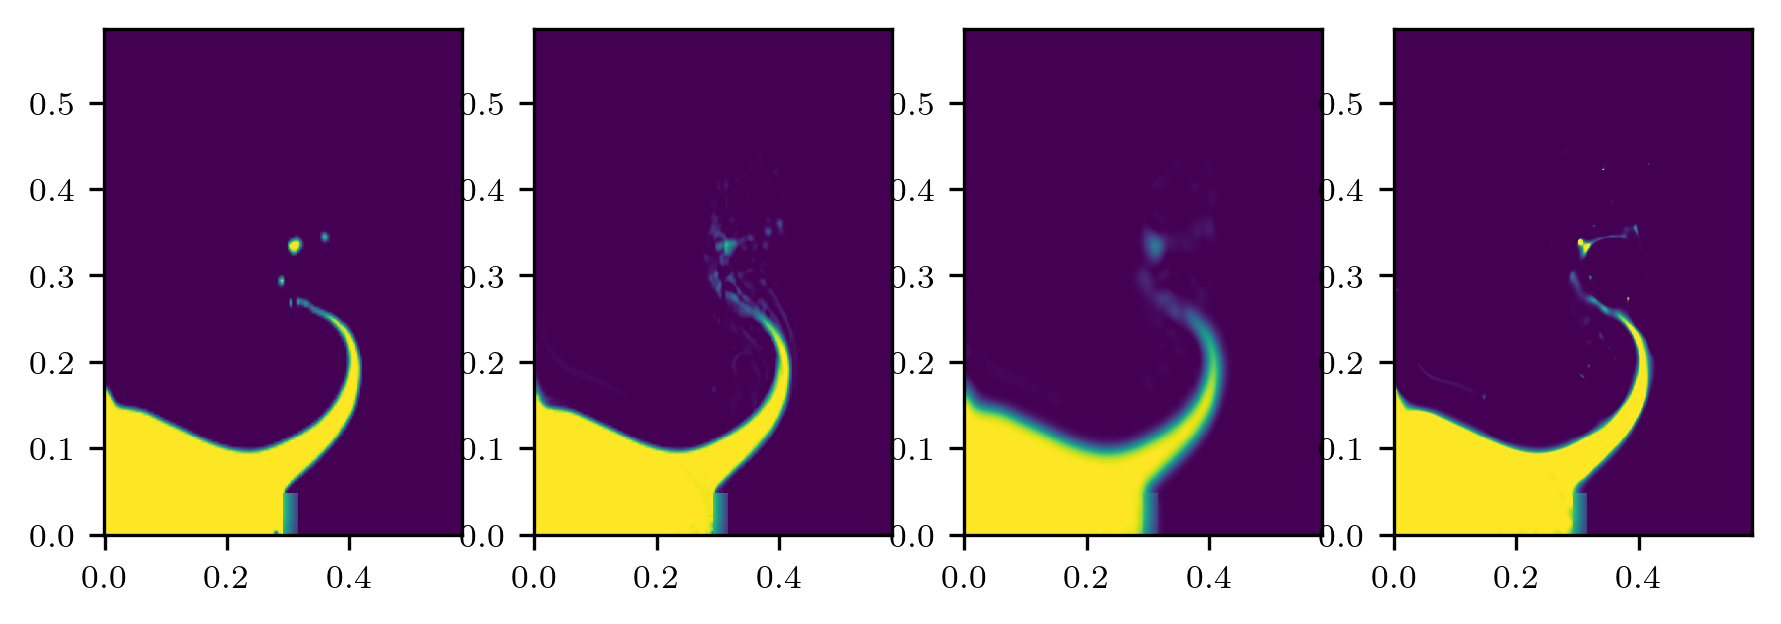

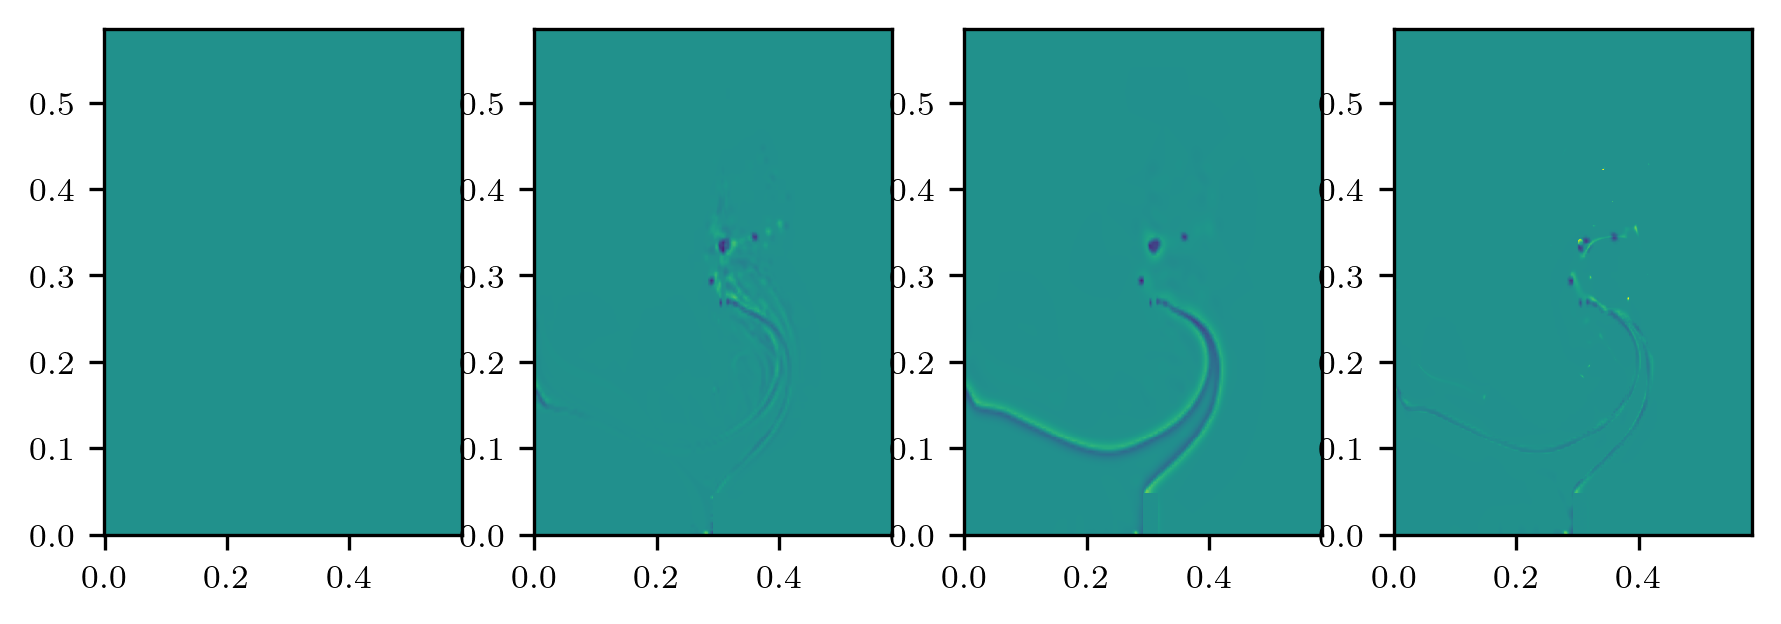

15 0.0 -0.09567477215072008 -0.019726096 0.0
15 1.0 1.1079029351000844 1.0176103 1.0
15 33050.470610193726 33044.096873188486 33038.273 33015.324


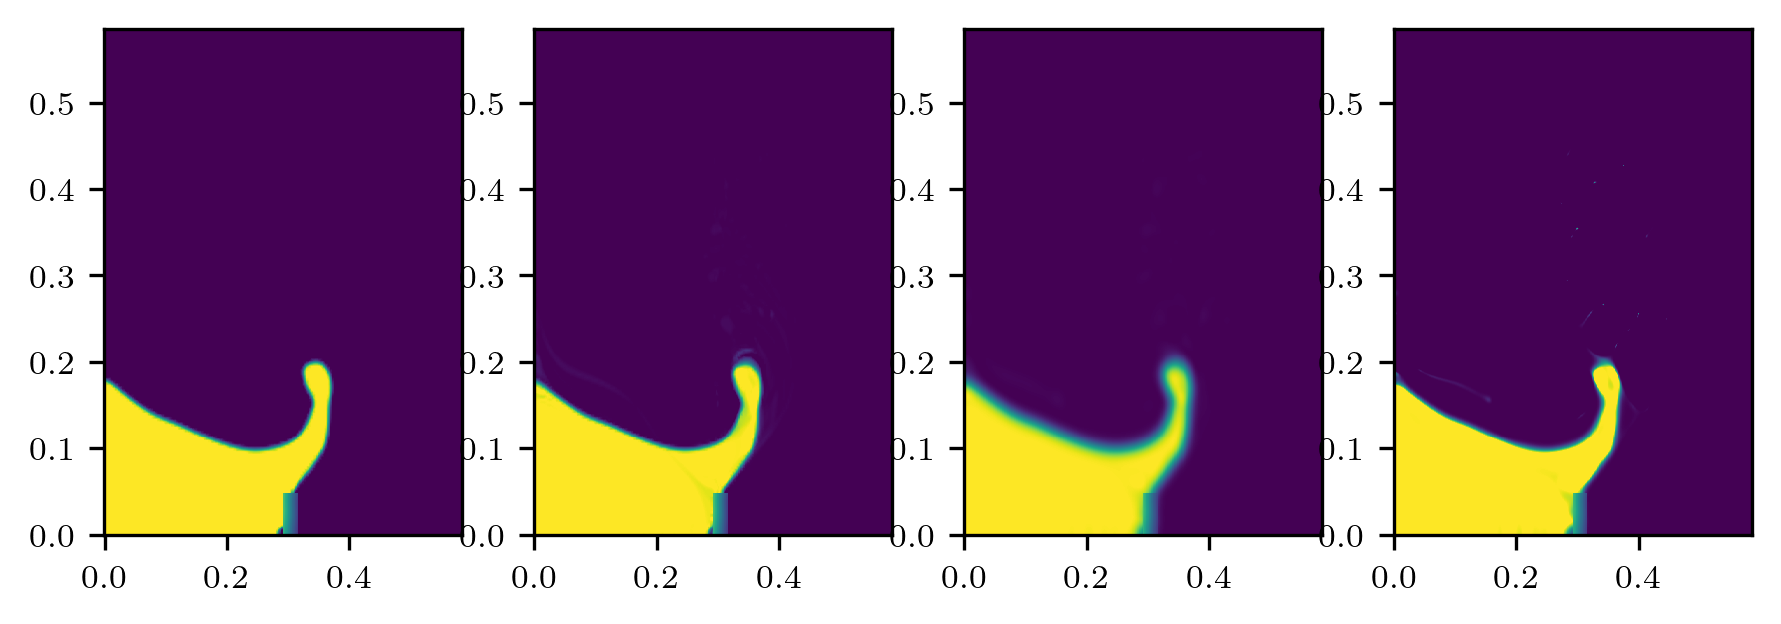

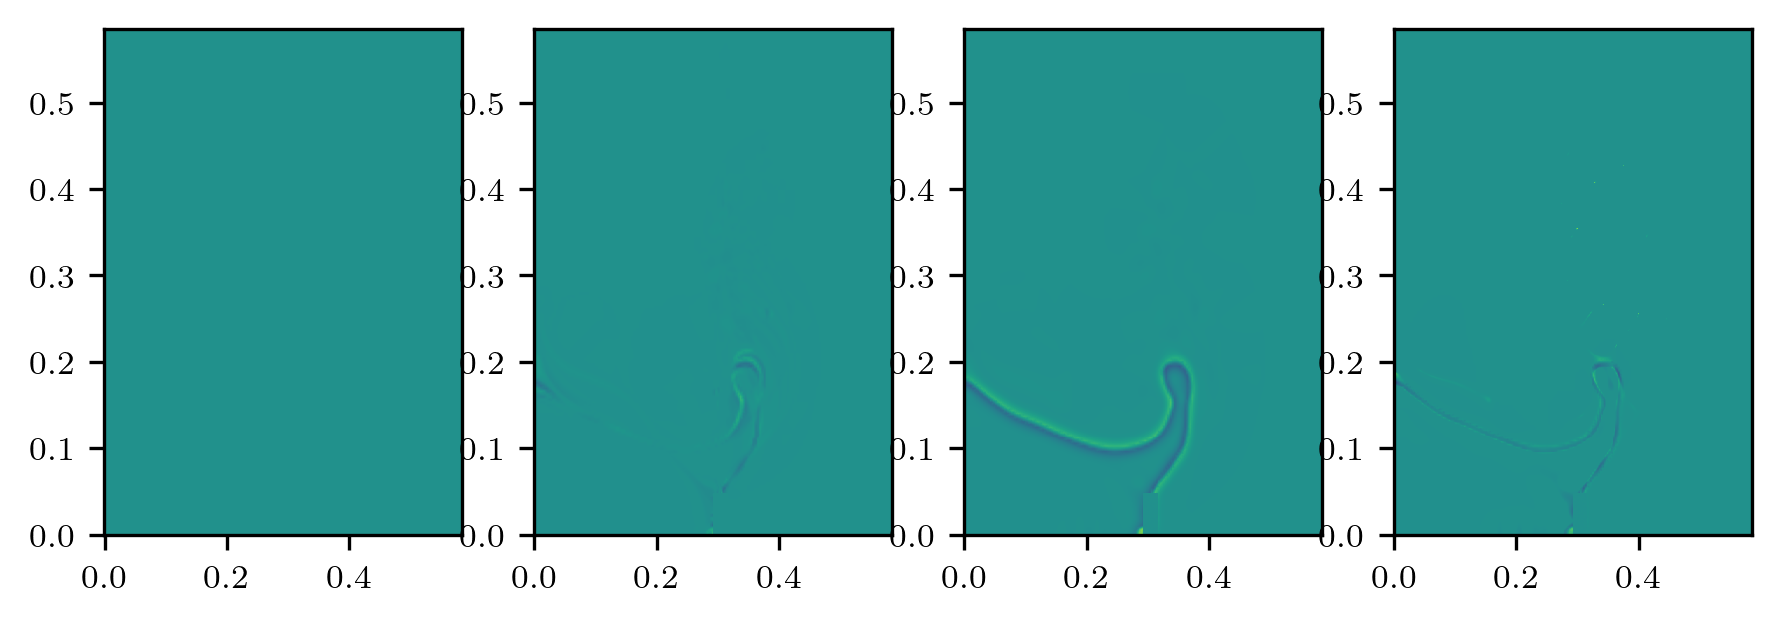

16 0.0 -0.08522683546992155 -0.12109379 0.0
16 1.0 1.2049734269425652 1.1224054 1.0
16 33084.31172538707 33159.60737194903 33142.664 33105.75


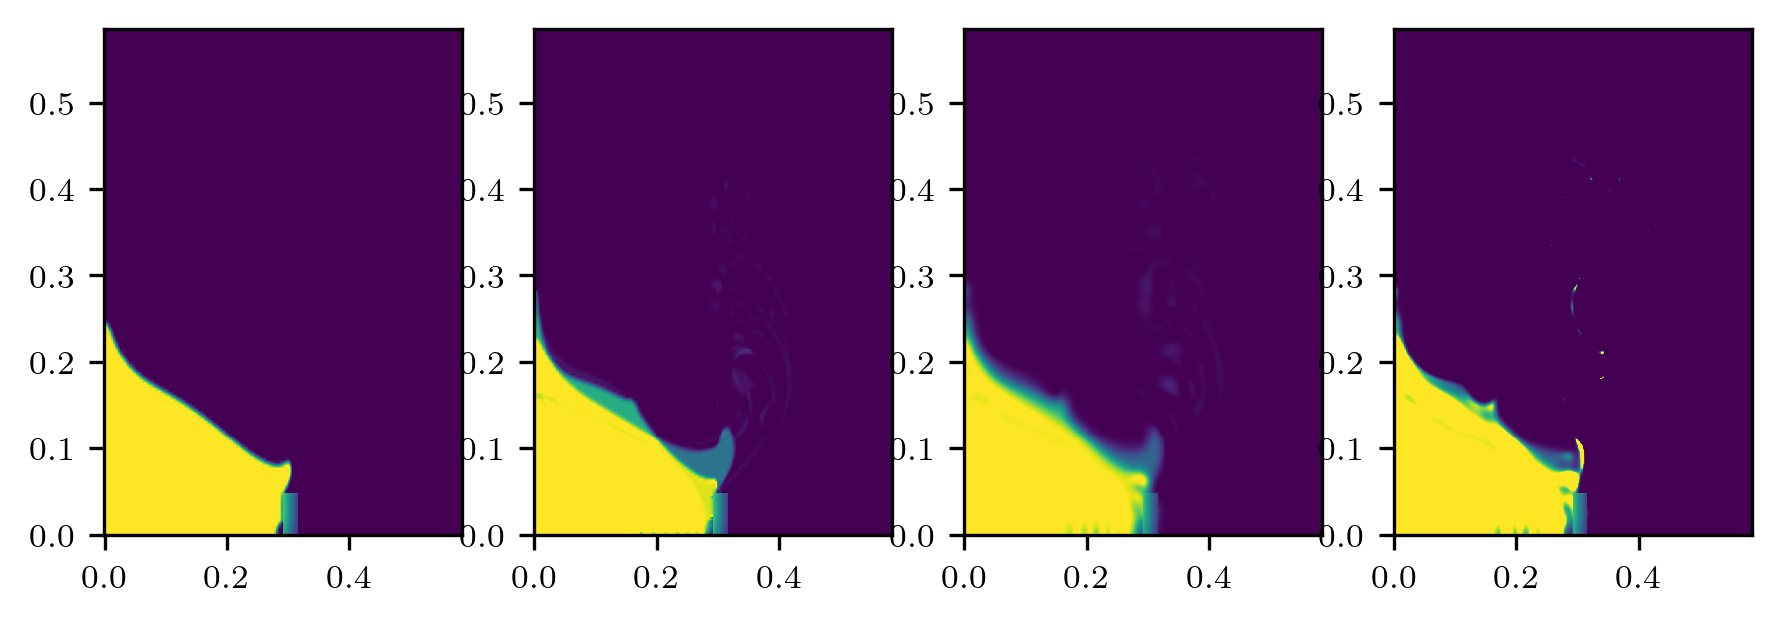

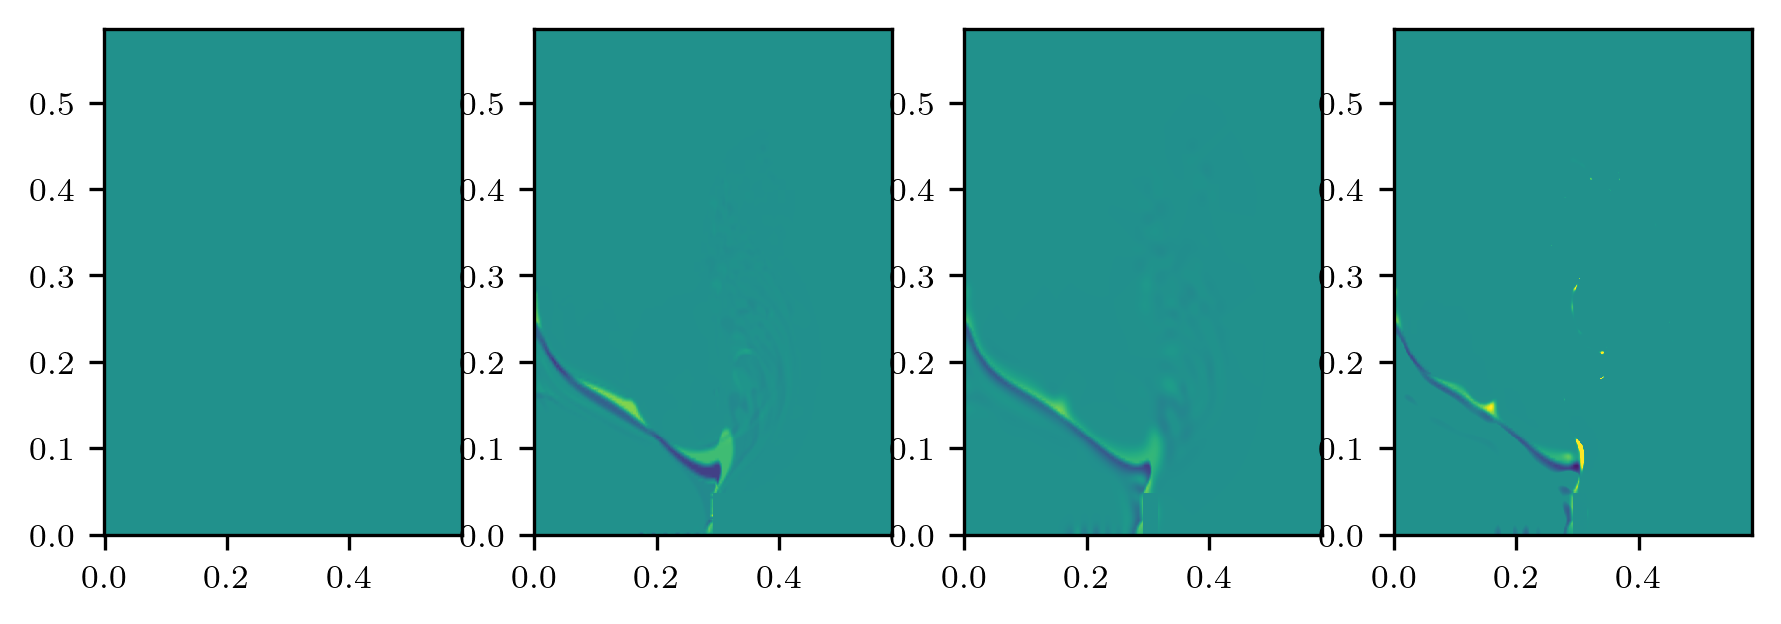

17 0.0 -0.10251517138079398 -0.011922717 0.0
17 1.0 1.1489022505764077 1.0118991 1.0
17 33049.58492189141 33052.00330217062 33037.5 33021.176


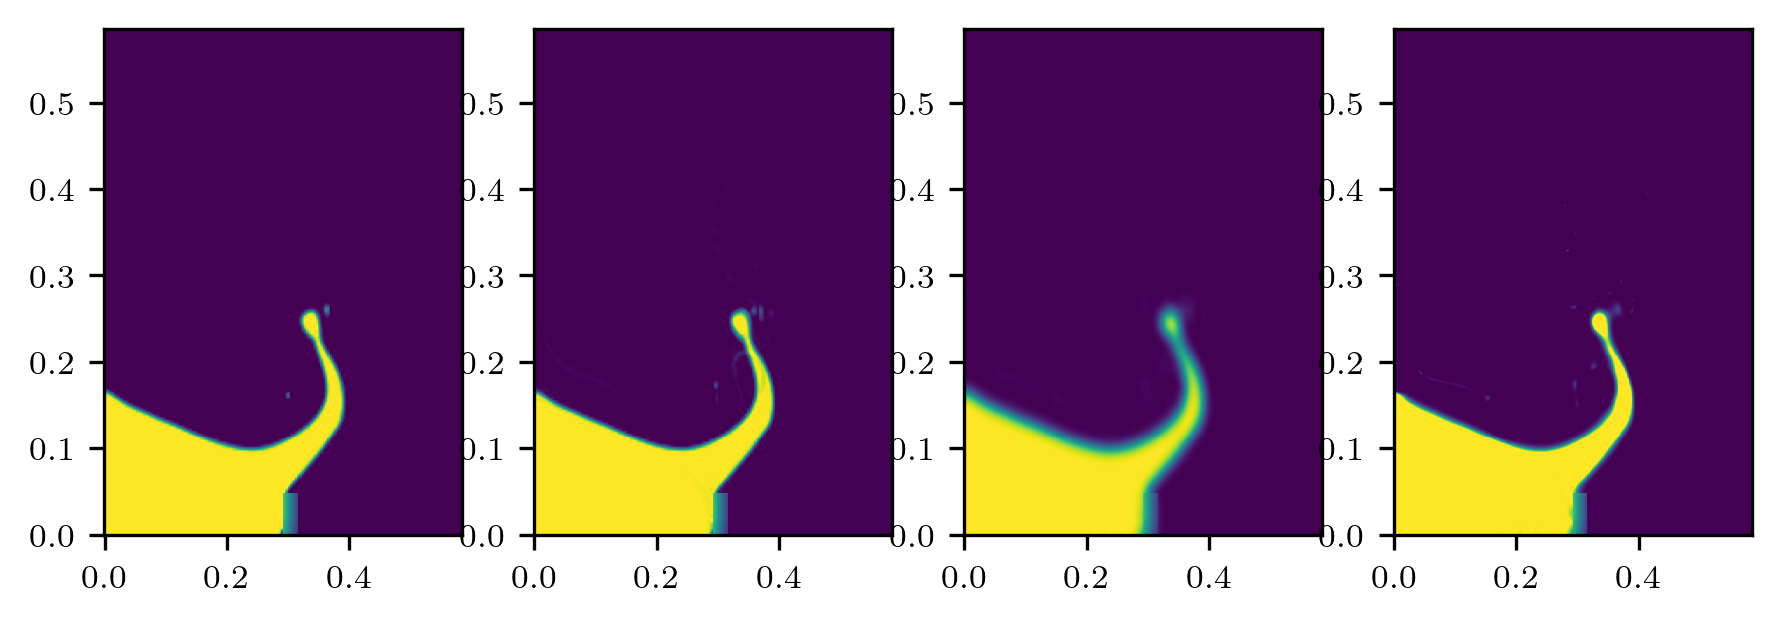

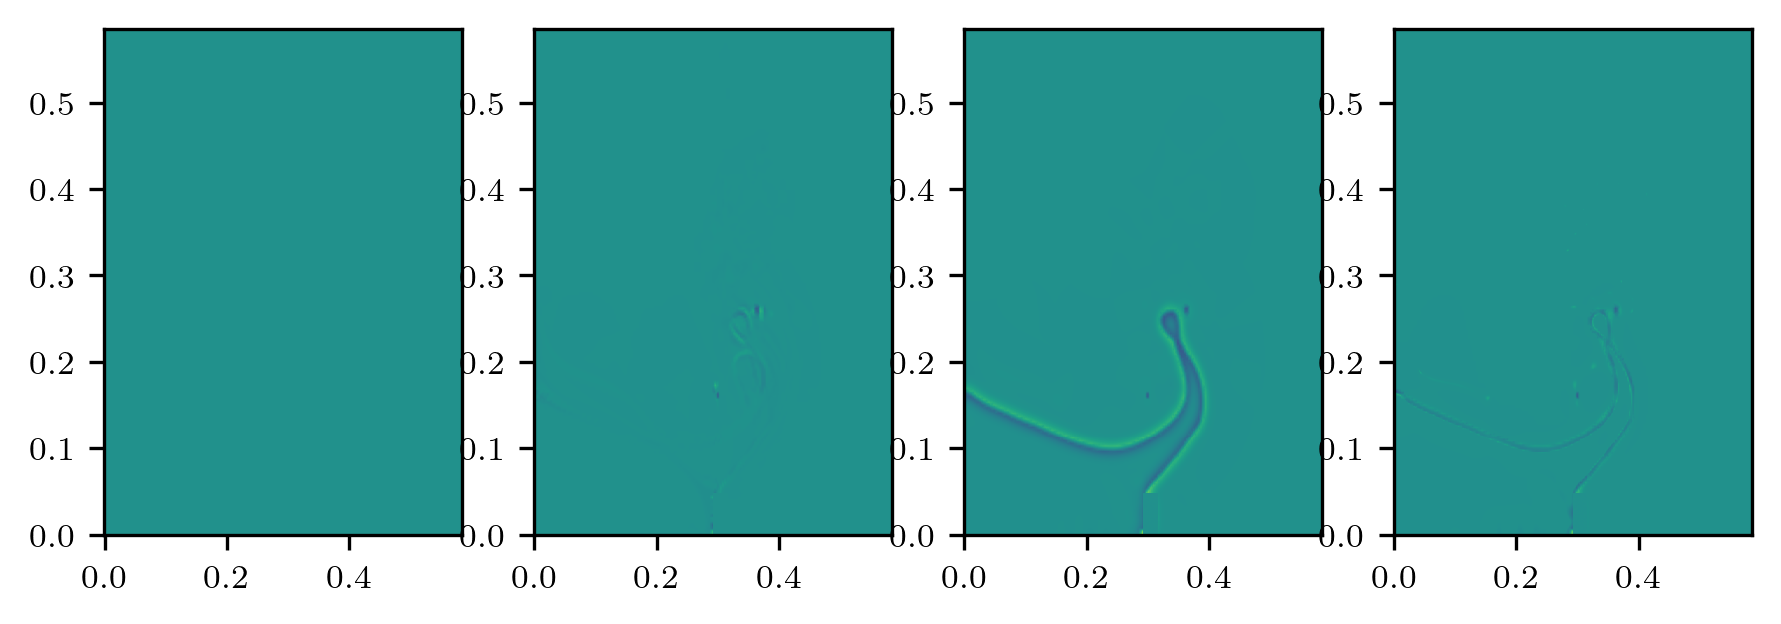

18 0.0 -0.11507323462184017 -0.0245601 0.0
18 1.0 1.0653113525276483 1.0111022 1.0
18 33090.115404890166 33088.831325742416 33072.37 33057.203


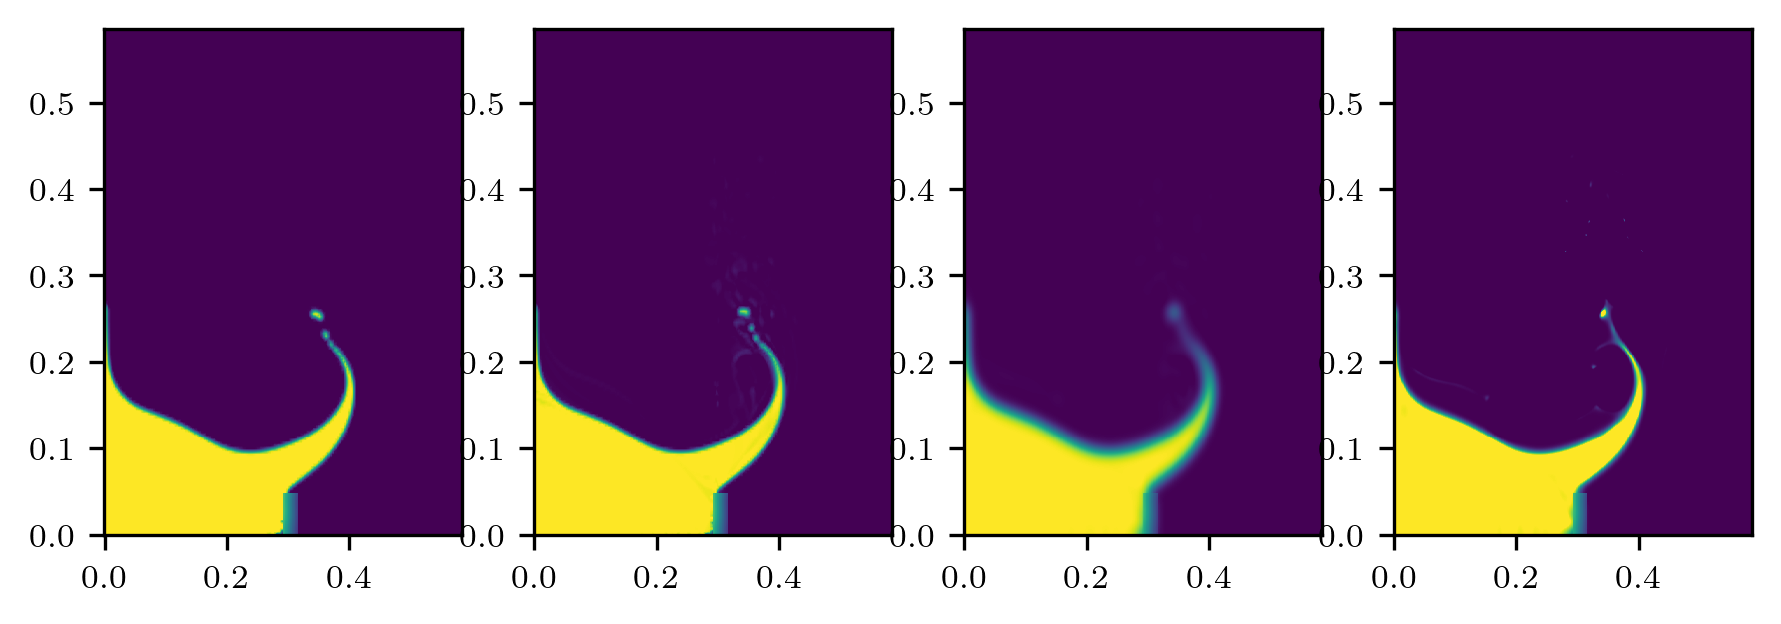

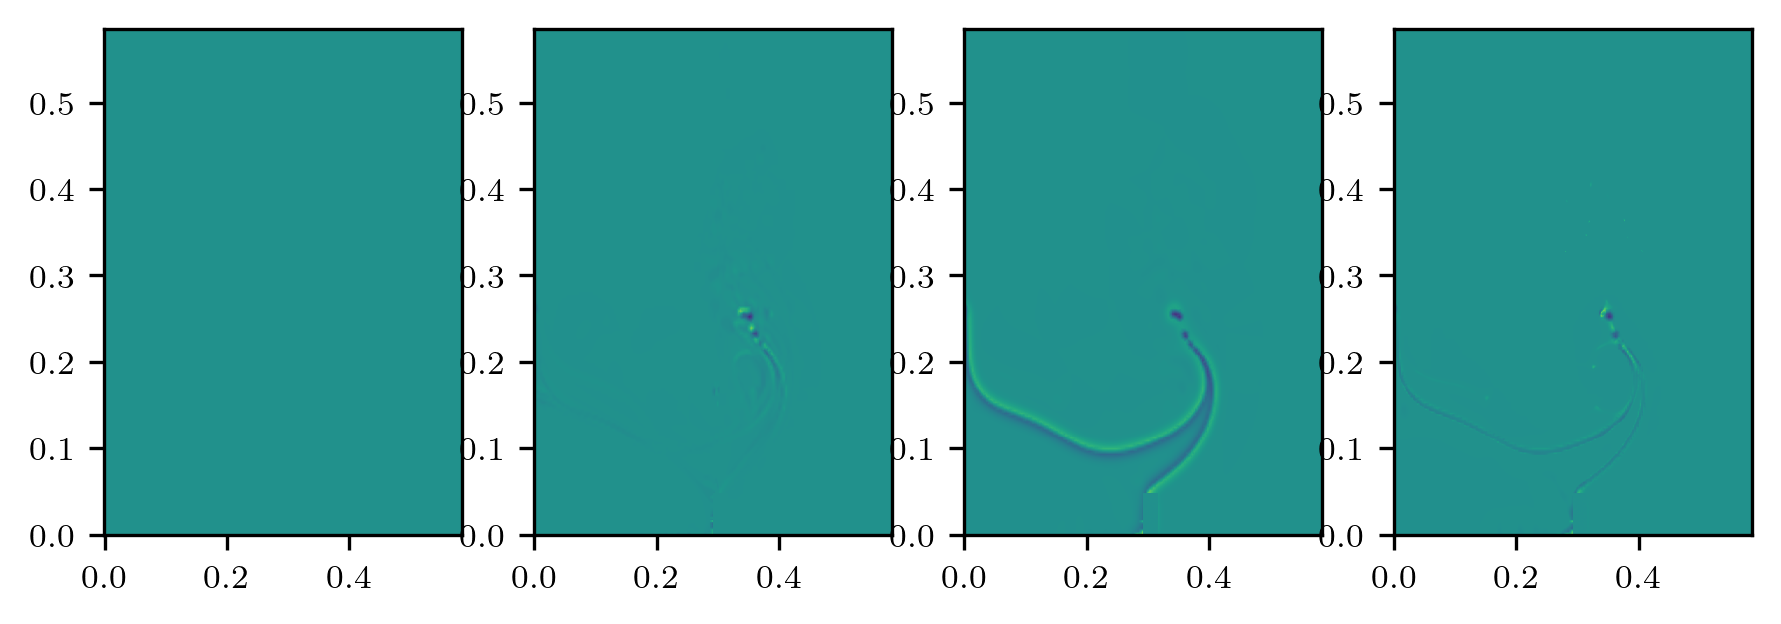

19 0.0 -0.2167958884434702 -0.055785123 0.0
19 1.0 1.2045159929427915 1.0233852 1.0
19 33050.12420947365 33060.022550233945 33076.027 33077.906


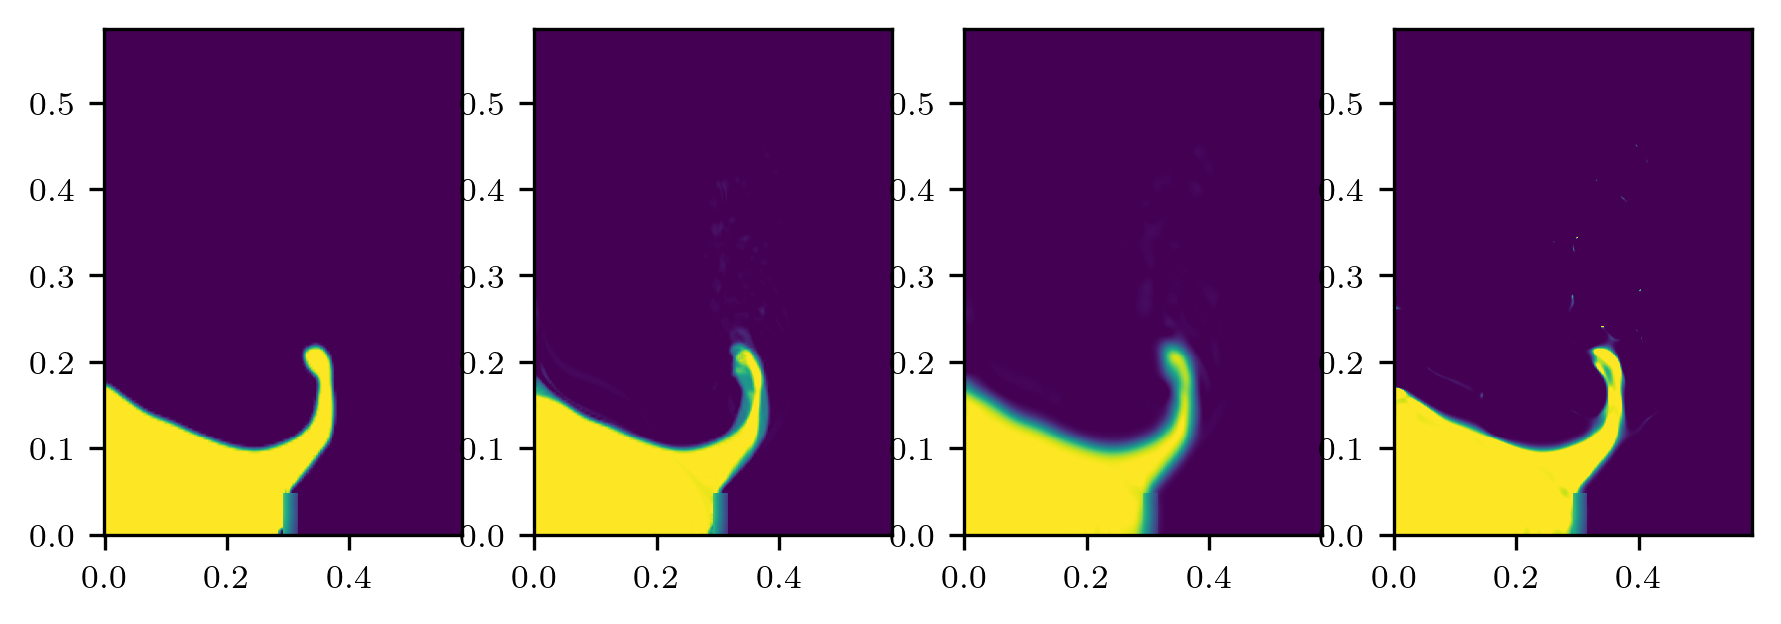

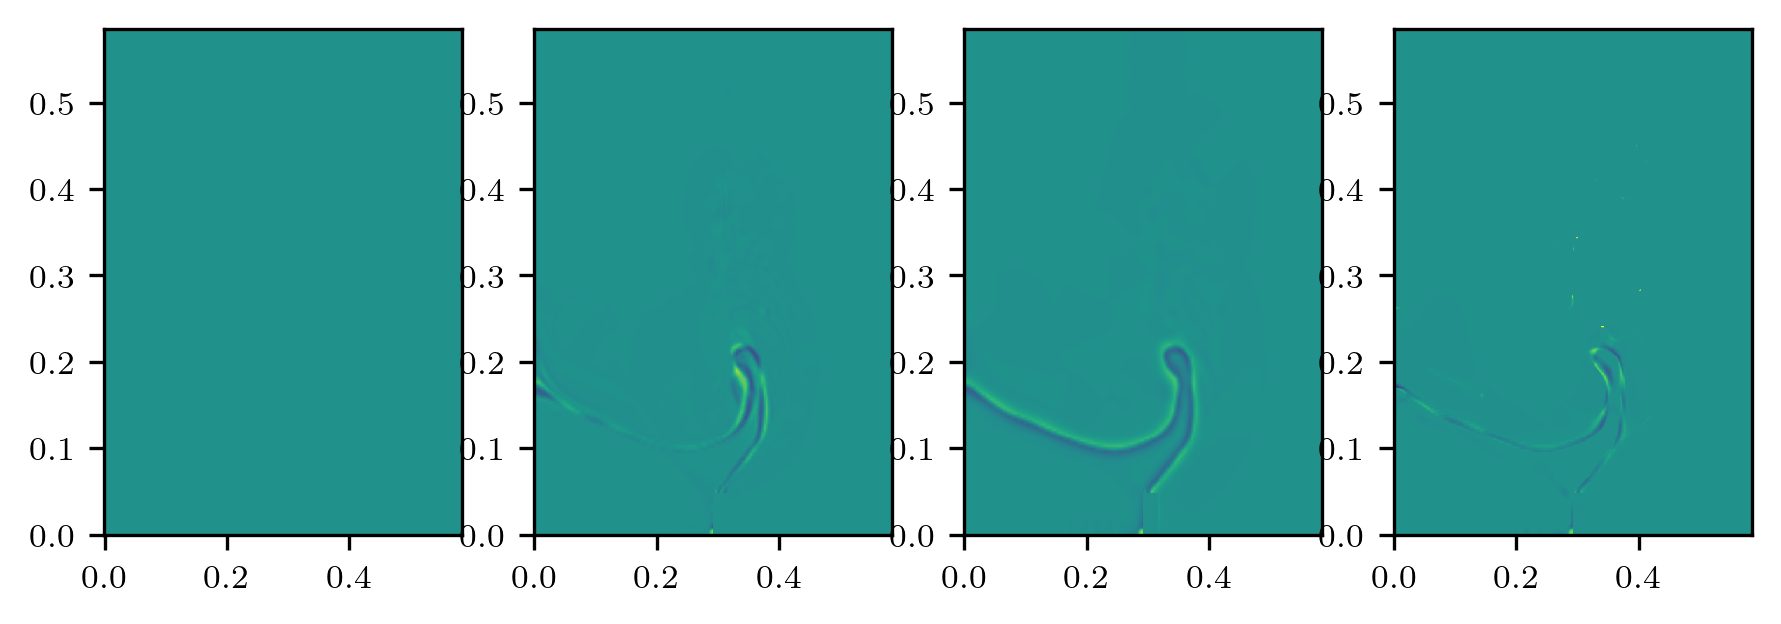

In [17]:
for i in range(20):
    print(i, np.min(X_test_grid[i]), np.min(X_test_ROM[i]), np.min(X_test_sROM[i]), np.min(X_test_sROMs[i]))
    print(i, np.max(X_test_grid[i]), np.max(X_test_ROM[i]), np.max(X_test_sROM[i]), np.max(X_test_sROMs[i]))
    print(i, np.sum(X_test_grid[i]), np.sum(X_test_ROM[i]), np.sum(X_test_sROM[i]), np.sum(X_test_sROMs[i]))
    fig,axs = plt.subplots(1, 4, figsize=(single_column_in*2, single_column_in/1.618))
    axs[0].pcolormesh(X, Y, X_test_grid[i].reshape(case["shape"]), vmin=0, vmax=1)
    axs[1].pcolormesh(X, Y, X_test_ROM[i].reshape(case["shape"]), vmin=0, vmax=1)
    axs[2].pcolormesh(X, Y, X_test_sROM[i].reshape(case["shape"]), vmin=0, vmax=1)
    axs[3].pcolormesh(X, Y, X_test_sROMs[i].reshape(case["shape"]), vmin=0, vmax=1)
    plt.show()
    fig,axs = plt.subplots(1, 4, figsize=(single_column_in*2, single_column_in/1.618))
    axs[0].pcolormesh(X, Y, (X_test_grid[i]-X_test_grid[i]).reshape(case["shape"]),vmin=-1,vmax=1)
    axs[1].pcolormesh(X, Y, (X_test_ROM[i]-X_test_grid[i]).reshape(case["shape"]),vmin=-1,vmax=1)
    axs[2].pcolormesh(X, Y, (X_test_sROM[i]-X_test_grid[i]).reshape(case["shape"]),vmin=-1,vmax=1)
    axs[3].pcolormesh(X, Y, (X_test_sROMs[i]-X_test_grid[i]).reshape(case["shape"]),vmin=-1,vmax=1)
    plt.show()

In [18]:
asd

NameError: name 'asd' is not defined

In [ ]:
def optimize_hyperparameters_3d(case, method="lbfgsb"):
    """
    Optimize (sigma, sigmaD, num_iter) to maximize improvement.
    method: "lbfgsb" (smooth, few evals) or "direct" (robust, more evals).
    Use this instead of DIRECT when the improvement surface is smooth.
    """
    sigma_opt = 0.013
    if "sigmaD" not in case or case["sigmaD"] is None:
        case["sigmaD"] = np.zeros((case["n_test"],))

    def target(params):
        case["sigma"], case["c"], case["num_iter"] = params[0], False, int(round(params[2]))
        case["sigmaD"][:] = params[1]
        return target_function(case)[2]

    bounds = ([0.001, 0.001, 1], [5 * sigma_opt, 5 * sigma_opt, 200])

    # Multi-start to reduce risk of bad local minimum
    starts = [
        np.array([0.0045, 0.0045, 14]),
    ]
    best_fun = np.inf
    best_x = None
    for x0 in starts:
        res = minimize(
            target,
            x0,
            method="L-BFGS-B",
           # method="SLSQP",
            bounds=list(zip(bounds[0], bounds[1])),
            options={"maxfun": 80, "ftol": 1e-4, "eps": np.array([0.00025, 0.00025, 3])},
        )
        print(res.x, res.fun)
        if res.fun < best_fun:
            best_fun = res.fun
            best_x = res.x
    x_best = best_x
    print(
        "L-BFGS-B result: sigma=%.5f sigmaD=%.5f num_iter=%d improvement=%.2f"
        % (x_best[0], x_best[1], int(round(x_best[2])), -best_fun)
    )
    return x_best
x_opt = optimize_hyperparameters_3d(case, method="lbfgsb")

In [ ]:
parameters = [0.011631372 , 0.011863069, 75]

In [ ]:
case["sigma"], case["c"], case["num_iter"] = parameters[0], False, int(parameters[2])
case["sigmaD"][:] = parameters[1]
sgm = case["sigma"] / case["dx"]
mode = case["mode"]
sD = case["sigmaD"][0]
if True:
    sgm = case["sigma"] / case["dx"]
    mode = case["mode"]
    sD = case["sigmaD"][0]
    print(case["sigma"],  case["c"], sD, case["num_iter"], end=" ")
    #for j in range(len(X_train_grid)):
    #    ss2D = X_train_grid[j].reshape(case["shape"])
    #    X_train_grid_s[j] = gaussian_filter(ss2D, sigma=sgm, truncate=10, mode='reflect').ravel()
    out = gaussian_filter_gpu(X_train_grid_gpu, sigma=(0, sgm, sgm), mode=mode)
    m1 = cp.sum(out, axis=(1,2), keepdims=True)
    out = out * cp.where(m1 > 0, m0 / m1, 1.0)
    X_train_grid_s = cp.asnumpy(out).reshape(len(X_train_grid), -1)


    my_ROM = train_ROM_rw(mu_train, X_train_grid)
    my_sROM = train_ROM_rw(mu_train, X_train_grid_s)
    
    X_test_ROM = my_ROM.predict(mu_test).snapshots_matrix
    X_test_sROM, X_test_sROMs = get_predictions_gpu(my_sROM, mu_test, **case)

    rmv_wall_inplace(X_test_ROM)
    rmv_wall_inplace(X_test_sROM)
    rmv_wall_inplace(X_test_sROMs)

    mean_ROM, mean_sROM, mean_sROMs, improvement = get_improvement(
        X_test_grid, X_test_ROM, X_test_sROM, X_test_sROMs, norm=L2_error_rw, scaler=None
    )
    print(mean_ROM, mean_sROM, mean_sROMs, improvement)
    
    e_ROM = L2_error_rw(X_test_ROM, X_test_grid)
    e_sROMs = L2_error_rw(X_test_sROMs, X_test_grid)
    imprmt_perss = 100 * e_sROMs / e_ROM - 100
    print(imprmt_perss)

In [ ]:
mean_ROM, mean_sROM, mean_sROMs, improvement = get_improvement(
    X_test_grid, X_test_ROM, X_test_sROM, X_test_sROMs, norm=L2_error_rw, scaler=None
)
print(X_test_grid.shape, X_test_ROM.shape, X_test_sROM.shape, X_test_sROMs.shape)
print(mean_ROM, mean_sROM, mean_sROMs, improvement)

In [ ]:
i = 16
for i in range(20):
    print(i, np.min(X_test_grid[i]), np.min(X_test_ROM[i]), np.min(X_test_sROM[i]), np.min(X_test_sROMs[i]))
    print(i, np.max(X_test_grid[i]), np.max(X_test_ROM[i]), np.max(X_test_sROM[i]), np.max(X_test_sROMs[i]))
    print(i, np.sum(X_test_grid[i]), np.sum(X_test_ROM[i]), np.sum(X_test_sROM[i]), np.sum(X_test_sROMs[i]))
    fig,axs = plt.subplots(1, 4, figsize=(single_column_in*2, single_column_in/1.618))
    axs[0].pcolormesh(X, Y, X_test_grid[i].reshape(case["shape"]))
    axs[1].pcolormesh(X, Y, X_test_ROM[i].reshape(case["shape"]))
    axs[2].pcolormesh(X, Y, X_test_sROM[i].reshape(case["shape"]))
    axs[3].pcolormesh(X, Y, X_test_sROMs[i].reshape(case["shape"]))
    plt.show()
    fig,axs = plt.subplots(1, 4, figsize=(single_column_in*2, single_column_in/1.618))
    axs[0].pcolormesh(X, Y, (X_test_grid[i]-X_test_grid[i]).reshape(case["shape"]),vmin=-1,vmax=1)
    axs[1].pcolormesh(X, Y, (X_test_ROM[i]-X_test_grid[i]).reshape(case["shape"]),vmin=-1,vmax=1)
    axs[2].pcolormesh(X, Y, (X_test_sROM[i]-X_test_grid[i]).reshape(case["shape"]),vmin=-1,vmax=1)
    axs[3].pcolormesh(X, Y, (X_test_sROMs[i]-X_test_grid[i]).reshape(case["shape"]),vmin=-1,vmax=1)
    plt.show()